# 🧐 Beyond Weird: Context-Aware Detection of Suspicious Music Streaming

*A clustering + anomaly-detection study on the Yambda music-streaming dataset.*

---

## 📚 Abstract

Streaming-music fraud — bot accounts and scripted plays inflating artist revenue — is estimated to account for 3–4% of all streams and up to $2B in lost value annually.¹ But detecting it is hard, because real listening is heterogeneous: some users loop one song fifty times, others skip through twenty tracks in three minutes, others disappear for a week and come back at 2 a.m.

This project asks: **how do you tell a scam from merely strange behavior?**

We approach the problem in three layered research questions:

- **RQ1** — segment users into interpretable behavioral archetypes (*lean-back loyal*, *casual explorers*, *active samplers*),
- **RQ2** — detect anomalies *within each archetype*, not globally,
- **RQ3** — ask whether those anomalies persist when users change archetypes over time.

**Headline findings.** Three stable archetypes explain most listening variation; anomaly has a different signature in each one (a loyal listener flagged for being *too loyal*; an explorer for being *too regular*; a sampler for sampling the *same thing*); and most flagged anomalies are state-dependent — they dissolve when the user's listening mode shifts — while a small persistent subset survives across transitions and also shows coordinated-network signatures. We output a three-tier **risk framework**, not a global score.

¹ IFPI Global Music Report 2026. Full reference at the end of this notebook.


## ⁉️ Motivation

### Streaming fraud is a real business problem

Global recorded-music revenue passed \$30B in 2025. Streaming accounts for the majority of it. And a conservatively estimated 3–4\% of streams — roughly $2B of revenue — is generated by bots, scripts, or coordinated stream farms that never correspond to a human pressing play.

### But not every weird listener is a bot

Music streaming is messy. Normal users do surprisingly weird-looking things:

- Someone loops their favorite song fifty times in one sitting to boost their Spotify Wrapped top-track rank.
- Someone skips through twenty tracks in three minutes while looking for the right vibe.
- Someone disappears for a week and comes back listening at 2 a.m.

Any of those, viewed in isolation, could look suspicious. The central methodological challenge: **how do we tell a scam from strange?**

### One definition of "normal" doesn't work

If we use a single global standard of "normal listening," we flag real people for just being different from majority. This project's core thesis is that **you have to understand what kind of listener someone is before you can judge whether their behavior is suspicious**. That thesis is what drives the RQ1 → RQ2 → RQ3 structure:

1. First map the space of normal listening (RQ1),
2. Then define anomaly *relative to where the user sits in that space* (RQ2),
3. Then test whether anomaly survives when the user moves through that space (RQ3).


## 👓 How to read this notebook

This notebook is structured as a linear narrative:

1. **RQ1 — Segment users into behavioral types.** Cluster the population into interpretable archetypes using engineered behavioral features + four clustering algorithms (K-Means, Ward hierarchical, HDBSCAN, GMM) + three robustness checks (temporal, tenure, feature-removal).
2. **Deep-dive appendix — Cluster validation.** Cluster dictionary, representative personas, Cohen's d effect sizes, sub-archetypes of flagged users, raw trace inspection. Evidence for the segmentation.
3. **RQ2 — Bot-like user detection.** Engineer mechanical-behavior features (timing regularity, item concentration), run one Isolation Forest globally and one per archetype, compare. Describe *what suspiciousness looks like* inside each archetype.
4. **RQ3 — Is suspiciousness persistent or state-dependent?** Build a weekly user-week panel, assign archetypes week-by-week via the RQ1 centroids, score anomaly within each cluster-week, and classify flagged users into four persistence types. Use temporal + network signals as supporting evidence. Produce a layered risk tier framework.
5. **Conclusion — What we learned.** Six-point summary, with the practical implication that fraud detection in streaming needs *stratification*, not *classification*.

All data operations use DuckDB over the parquet listens/feedback tables. Feature engineering is deterministic and reproducible given a seed. Outputs (cluster labels, anomaly scores, persistence types, risk tier) are all attached to the per-user `anomaly_table` and per-(user, week) `panel` DataFrames for downstream use.


---
# RQ1 — Segment users into behavioral types🏘️

**Goal.** Cluster users into interpretable behavioral archetypes.

**Algorithm.** K-means clustering on behavioral features.

**Why this approach.** We chose **k-means** because K-means provides simple centroid-based clusters that can be directly profiled and compared across behavioral features, making it well suited for building listener archetypes that are easy to explain and use downstream. It also creates a clean foundation for RQ2 and RQ3, where anomaly is judged relative to behavioral context rather than against one global baseline.

## 0. Setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
PROJECT_DIR = '/content/drive/MyDrive/Data Mining/Project/BeyondWeird'
os.chdir(PROJECT_DIR)
print('Working directory:', os.getcwd())
print('Files here:', sorted(os.listdir('.')))

Mounted at /content/drive
Working directory: /content/drive/MyDrive/Data Mining/Project/BeyondWeird
Files here: ['Main.ipynb', 'README.md', 'preprocessing.py']


In [ ]:
!pip -q install duckdb hdbscan scikit-learn matplotlib seaborn pandas pyarrow

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import duckdb
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from math import pi

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, MiniBatchKMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from scipy.cluster.hierarchy import dendrogram, linkage
import hdbscan

import random, os
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

# preprocessing.py holds all data-prep logic (RQ1, RQ2, RQ3) so this notebook
# stays focused on analysis rather than wrangling.
from preprocessing import (
    # RQ1
    load_or_build_features,
    compute_features_for_period,
    auto_archetype_map,
    # RQ2
    build_anomaly_table,
    # RQ3
    build_weekly_feature_tables,
    assign_weekly_archetypes,
    score_weekly_anomalies,
    build_coordination_events,
    build_repeated_peers,
    DEFAULT_DATA_URL as DATA,
)

print('Imports ready · SEED =', SEED)


Imports ready · SEED = 42


## 1. Feature engineering

The heavy lifting — downloading the 50M-event Yambda parquet, sessionizing listens, computing per-user aggregates — lives in `preprocessing.py` so this notebook stays focused on analysis rather than data wrangling. The function below either loads a cached parquet from `./data/` (fast) or rebuilds everything from the raw source on first run (slow, a few minutes) and then caches it.

We derive per-user features in five groups that together capture *what kind of listener* someone is:

| Group | Example features | What it captures |
|---|---|---|
| **Activity** | `events_per_day`, `listens_per_day`, `n_sessions` | Overall engagement level |
| **Engagement quality** | `played_ratio_med`, `very_short_play_share`, `full_rate_med` | How deeply users listen |
| **Context** | `organic_share` | Self-directed vs. algorithmic listening |
| **Repetition** | `repeat_session_rate`, `imm_repeat_rate_med` | Replay / exploitation tendency |
| **Catalog breadth** | `n_unique_items_per_session_med`, `item_entropy` | Exploration width |
| **Explicit feedback** | `rate_like`, `rate_unlike` | Active taste curation |

Heavy-tailed count features are log-transformed before clustering.

The function returns three tables:
- **`listens`** — event-level records with session IDs and derived skip/full/repeat flags. Used throughout RQ2 and RQ3.
- **`sess`** — one row per session, used for deep-dive profiling.
- **`user_features`** — one row per user, the direct input to clustering in the next section.


In [ ]:
from preprocessing import load_or_build_features

# First run: downloads + processes the dataset, writes cache to ./data/ (~few minutes).
# Subsequent runs: just loads the parquet cache (seconds).
# Pass force_rebuild=True to ignore the cache.
listens, sess, user_features = load_or_build_features()

print(f'\nuser_features shape: {user_features.shape}')
user_features.head(3)


No cache found at data/ → building from source...
(This takes a few minutes on the full 50M-event dataset.)
  [1/4] user activity + feedback from all events...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

        10,000 users
  [2/4] loading listens + sessionizing...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

        46,467,212 listen events
  [3/4] session-level aggregates...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

        5,083,339 sessions across 9,238 users
  [4/4] item diversity (entropy) per user...
        dropped 0 users with < 5 listens
        final user_features: (9238, 29)

Writing cache to data/ ...
Done.

user_features shape: (9238, 29)


,uid,n_events,n_items,organic_share,t_span_days,n_listens,n_likes,n_unlikes,n_dislikes,n_undislikes,...,skip_rate_med,full_rate_med,repeat_session_rate,repeat_event_rate_med,imm_repeat_rate_med,played_ratio_med,played_ratio_iqr,very_short_play_share,item_entropy,catalog_breadth
0,100,3615,893,0.358506,1500.388889,3585.0,20.0,5.0,3.0,2.0,...,0.000000,0.903994,0.0,0.0,0.0,97.100000,0.000,0.0,9.096383,0.249093
1,200,354,224,1.000000,643.961227,354.0,0.0,0.0,0.0,0.0,...,0.058462,0.918333,0.0,0.0,0.0,93.101667,0.000,0.0,7.637868,0.632768
2,300,764,395,0.989529,1496.130498,704.0,44.0,16.0,0.0,0.0,...,0.226496,0.450000,0.0,0.0,0.0,65.750000,3.375,0.0,8.224702,0.561080


## 2. Feature preparation

Before clustering we:
1. Log transformation to highly skewed features
2. Remove highly correlated features
3. Standardization

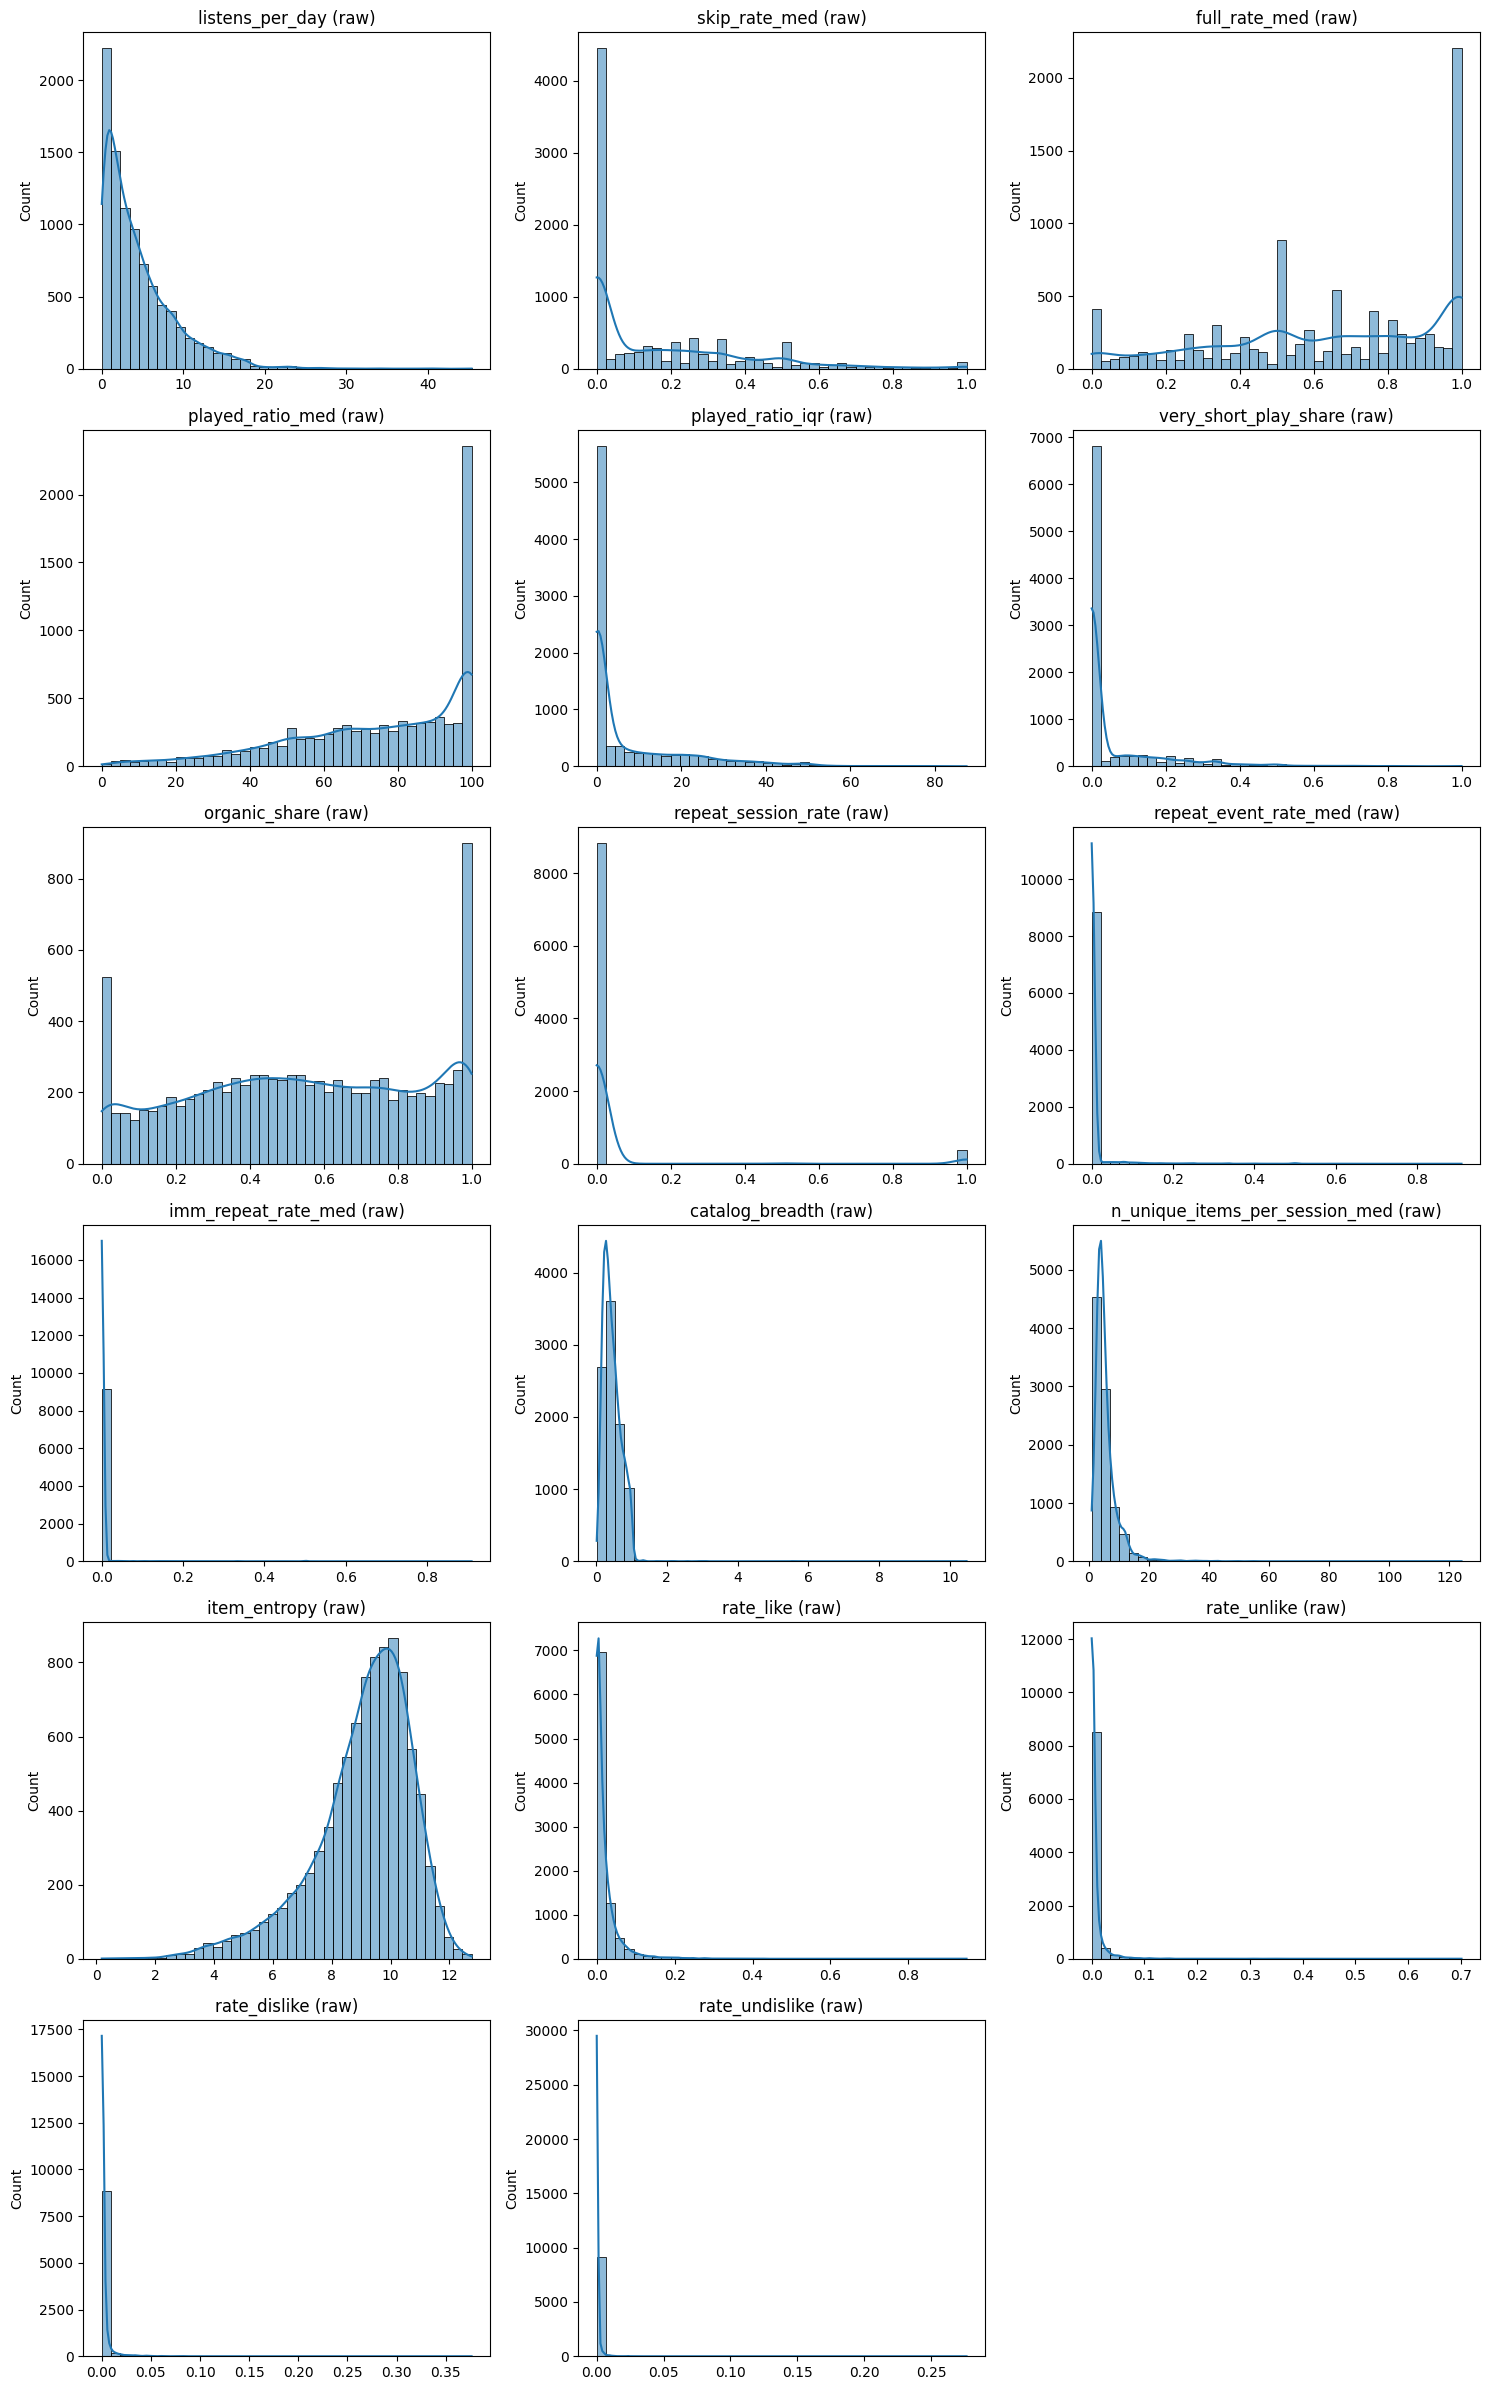

In [ ]:
# ── Plot candidate variables ──────────────
import math
import matplotlib.pyplot as plt
import seaborn as sns

candidate_cols = [
    "listens_per_day",
    "skip_rate_med",
    "full_rate_med",
    "played_ratio_med",
    "played_ratio_iqr",
    "very_short_play_share",
    "organic_share",
    "repeat_session_rate",
    "repeat_event_rate_med",
    "imm_repeat_rate_med",
    "catalog_breadth",
    "n_unique_items_per_session_med",
    "item_entropy",
    "rate_like",
    "rate_unlike",
    "rate_dislike",
    "rate_undislike",
]

plot_df = user_features[candidate_cols].copy()

n = len(candidate_cols)
ncols = 3
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4*nrows))
axes = axes.flatten()

for ax, col in zip(axes, candidate_cols):
    sns.histplot(plot_df[col].dropna(), bins=40, kde=True, ax=ax)
    ax.set_title(f"{col} (raw)")
    ax.set_xlabel("")

for ax in axes[n:]:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# ── Select and transform features───────────────
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

user_features = user_features.copy()
user_features["catalog_breadth"] = (
    user_features["n_items"] / user_features["n_listens"].clip(lower=1)
)

# combine sparse feedback signals into a more stable total feedback rate
user_features["feedback_rate"] = (
    user_features["rate_like"].fillna(0)
    + user_features["rate_unlike"].fillna(0)
    + user_features["rate_dislike"].fillna(0)
    + user_features["rate_undislike"].fillna(0)
)

# create one compact activity control instead of many raw size features
user_features["activity_level"] = np.log1p(
    user_features["listens_per_day"].fillna(0)
)

FEATURE_COLS = [
    # ── Compact activity control ──
    "activity_level",

    # ── Engagement quality ──
    "skip_rate_med",
    "full_rate_med",
    "played_ratio_med",
    "played_ratio_iqr",
    "very_short_play_share",

    # ── Context ──
    "organic_share",

    # ── Repetition ──
    "repeat_session_rate",
    "repeat_event_rate_med",
    "imm_repeat_rate_med",

    # ── Exploration / diversity ──
    "catalog_breadth",
    "n_unique_items_per_session_med",
    "item_entropy",

    # ── Explicit feedback ──
    "rate_like",
    "rate_unlike",
    "rate_dislike",
    "rate_undislike",
    "feedback_rate"
]

LOG_COLS = [
    "n_unique_items_per_session_med",
    "catalog_breadth",
    "rate_like",
    "rate_unlike",
    "rate_dislike",
    "rate_undislike"
]

feat = user_features[FEATURE_COLS].copy()

# Fill missing values if any
feat = feat.fillna(feat.median(numeric_only=True))

# Winsorize to reduce extreme outlier influence
for c in feat.columns:
    lo, hi = feat[c].quantile([0.01, 0.99])
    feat[c] = feat[c].clip(lo, hi)

# Log-transform selected skewed columns
for c in LOG_COLS:
    feat[c] = np.log1p(feat[c])

# Standardize
scaler = StandardScaler()
X = scaler.fit_transform(feat)

print(f"Feature matrix shape: {X.shape}  ({len(FEATURE_COLS)} features × {len(feat):,} users)")
print("Features used:")
print(FEATURE_COLS)

Feature matrix shape: (9238, 18)  (18 features × 9,238 users)
Features used:
['activity_level', 'skip_rate_med', 'full_rate_med', 'played_ratio_med', 'played_ratio_iqr', 'very_short_play_share', 'organic_share', 'repeat_session_rate', 'repeat_event_rate_med', 'imm_repeat_rate_med', 'catalog_breadth', 'n_unique_items_per_session_med', 'item_entropy', 'rate_like', 'rate_unlike', 'rate_dislike', 'rate_undislike', 'feedback_rate']


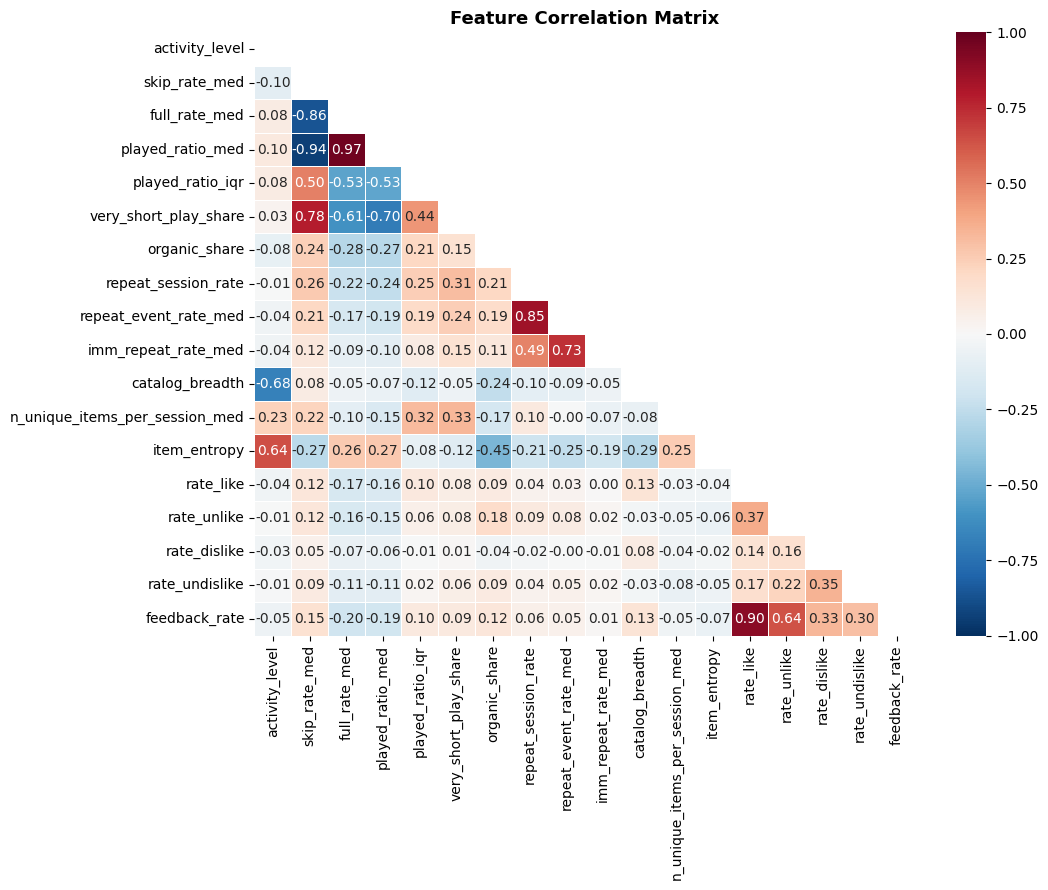

High-correlation pairs (|r| > 0.85):
  skip_rate_med  ↔  full_rate_med  : -0.861
  skip_rate_med  ↔  played_ratio_med  : -0.939
  full_rate_med  ↔  played_ratio_med  : 0.974
  rate_like  ↔  feedback_rate  : 0.905


In [ ]:
# ── Correlation heatmap ──────────────────────────────────────────────────
corr = feat.corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            annot=True, fmt='.2f', linewidths=0.4, ax=ax,
            xticklabels=FEATURE_COLS, yticklabels=FEATURE_COLS)
ax.set_title('Feature Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Flag highly correlated pairs (|r| > 0.85)
high_corr = [
    (FEATURE_COLS[i], FEATURE_COLS[j], round(corr.iloc[i, j], 3))
    for i in range(len(FEATURE_COLS))
    for j in range(i+1, len(FEATURE_COLS))
    if abs(corr.iloc[i, j]) > 0.85
]
print('High-correlation pairs (|r| > 0.85):')
for a, b, r in high_corr:
    print(f'  {a}  ↔  {b}  : {r}')

Most features are not dangerously redundant, which is good for clustering. The two clear exceptions are:

- `skip_rate_med` vs. `full_rate_med` → correlation **−0.86**
- `rate_like` vs. `feedback_rate` → correlation **+0.90**

For clustering we keep `full_rate_med` (more directly interpretable as play depth) and drop `skip_rate_med`, and we keep `rate_like` (strongest curation signal) and drop `feedback_rate` (which is dominated by likes anyway).


In [ ]:
FEATURE_COLS = [
    # ── Compact activity control ──
    "activity_level",

    # ── Engagement quality ──
    "played_ratio_med",
    "played_ratio_iqr",
    "very_short_play_share",

    # ── Context ──
    "organic_share",

    # ── Repetition ──
    "repeat_session_rate",
    "imm_repeat_rate_med",

    # ── Exploration / diversity ──
    "catalog_breadth",
    "n_unique_items_per_session_med",
    "item_entropy",

    # ── Explicit feedback ──
    "rate_like",
    "rate_unlike",
    "rate_dislike",
    "rate_undislike",
]

LOG_COLS = ["n_unique_items_per_session_med"]

feat = user_features[FEATURE_COLS].copy().fillna(user_features[FEATURE_COLS].median(numeric_only=True))

for c in LOG_COLS:
    feat[c] = np.log1p(feat[c])

scaler = StandardScaler()
X = scaler.fit_transform(feat)

PCA visualization helps assess whether meaningful cluster structure exists in the data before applying clustering algorithms.

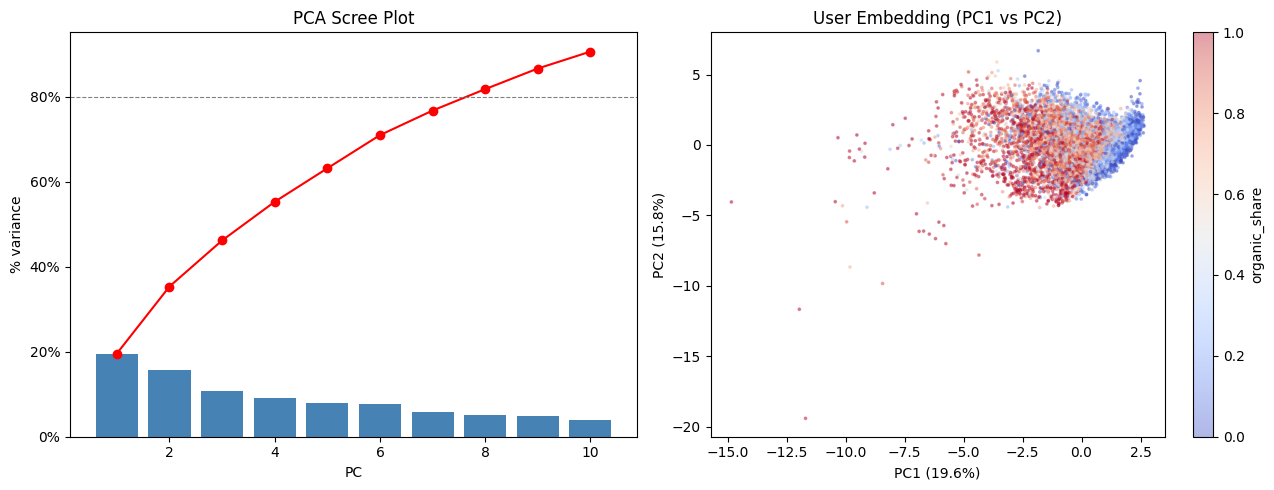


Top PC loadings:
                                  PC1    PC2    PC3
played_ratio_med                0.474 -0.170 -0.146
item_entropy                    0.370  0.376  0.225
activity_level                  0.215  0.510 -0.045
n_unique_items_per_session_med -0.058  0.404  0.307
rate_dislike                   -0.063 -0.064  0.289
rate_undislike                 -0.100 -0.082  0.193
catalog_breadth                -0.138 -0.423  0.414
rate_unlike                    -0.152 -0.075  0.159
rate_like                      -0.156 -0.123  0.343
imm_repeat_rate_med            -0.182 -0.026 -0.378
organic_share                  -0.300 -0.043 -0.381
repeat_session_rate            -0.315  0.135 -0.286
played_ratio_iqr               -0.341  0.311  0.086
very_short_play_share          -0.413  0.280  0.139


In [ ]:
# ── PCA — 2-D projection for visualization ───────────────────────────────
pca = PCA(n_components=10, random_state=SEED)
X_pca_full = pca.fit_transform(X)
X_2d = X_pca_full[:, :2]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scree plot
ev = pca.explained_variance_ratio_ * 100
axes[0].bar(range(1, len(ev)+1), ev, color='steelblue')
axes[0].plot(range(1, len(ev)+1), np.cumsum(ev), 'ro-')
axes[0].axhline(80, color='grey', linestyle='--', linewidth=0.8)
axes[0].set_xlabel('PC'); axes[0].set_ylabel('% variance')
axes[0].set_title('PCA Scree Plot')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}%'))

# 2-D projection coloured by organic_share
sc = axes[1].scatter(X_2d[:, 0], X_2d[:, 1],
                     c=user_features['organic_share'].values,
                     cmap='coolwarm', s=3, alpha=0.4)
plt.colorbar(sc, ax=axes[1], label='organic_share')
axes[1].set_xlabel(f'PC1 ({ev[0]:.1f}%)')
axes[1].set_ylabel(f'PC2 ({ev[1]:.1f}%)')
axes[1].set_title('User Embedding (PC1 vs PC2)')

plt.tight_layout()
plt.show()

# PC loadings
loadings = pd.DataFrame(pca.components_[:3].T,
                        index=FEATURE_COLS,
                        columns=['PC1','PC2','PC3']).sort_values('PC1', ascending=False)
print('\nTop PC loadings:')
print(loadings.round(3))

* No single dominant dimension → good (my preprocessing worked)
* Variance is spread across components → behavior is multi-dimensional
* The first two components alone don't perfectly separate the clusters — that's expected — but they show the clusters live on a smooth behavioral manifold rather than being arbitrary cuts in high-dimensional noise.

## 3. K-Means clustering

Sweep k = 2 … 8. Track silhouette and Davies–Bouldin to find the elbow.


  k=2  silhouette=0.2978  DB=2.2666  inertia=114682.2
  k=3  silhouette=0.1740  DB=1.8940  inertia=102473.1
  k=4  silhouette=0.1045  DB=2.1291  inertia=98275.1
  k=5  silhouette=0.1905  DB=1.4795  inertia=86154.9
  k=6  silhouette=0.1030  DB=1.6968  inertia=87523.3
  k=7  silhouette=0.1398  DB=1.9482  inertia=82807.0
  k=8  silhouette=0.1126  DB=1.8025  inertia=79115.6


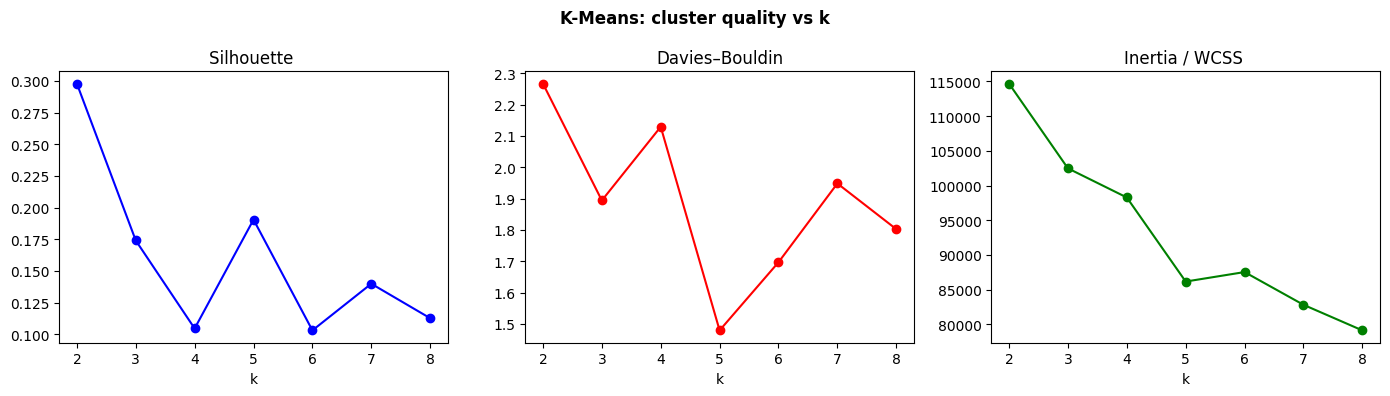

In [ ]:
# ── k sweep ─────────────────────────────────────────────────────────────
K_RANGE = range(2, 9)
sil_scores, db_scores, inertias = [], [], []

for k in K_RANGE:
    km = MiniBatchKMeans(n_clusters=k, n_init=10, batch_size=4096, random_state=SEED)
    labels = km.fit_predict(X)
    sil = silhouette_score(X, labels, sample_size=min(5000, len(X)), random_state=SEED)
    db  = davies_bouldin_score(X, labels)
    sil_scores.append(sil)
    db_scores.append(db)
    inertias.append(km.inertia_)
    print(f'  k={k}  silhouette={sil:.4f}  DB={db:.4f}  inertia={km.inertia_:.1f}')

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
ks = list(K_RANGE)
axes[0].plot(ks, sil_scores, 'bo-'); axes[0].set_title('Silhouette ')
axes[0].set_xlabel('k')
axes[1].plot(ks, db_scores,  'ro-'); axes[1].set_title('Davies–Bouldin')
axes[1].set_xlabel('k')
axes[2].plot(ks, inertias,   'go-'); axes[2].set_title('Inertia / WCSS ')
axes[2].set_xlabel('k')
plt.suptitle('K-Means: cluster quality vs k', fontweight='bold')
plt.tight_layout()
plt.show()

**Although k=5 slightly improves the Davies–Bouldin index and marginally increases the silhouette score compared to k=3, the overall silhouette values remain low across all k, indicating weak cluster separation. Combined with the PCA visualization, which suggests a continuous distribution of user behavior rather than distinct groups, this indicates that increasing k primarily partitions a smooth gradient rather than uncovering meaningful structure. Therefore, k=3 was selected to provide a simpler, more interpretable segmentation that captures the main behavioral differences without overfitting noise.**

Best k by silhouette: 3


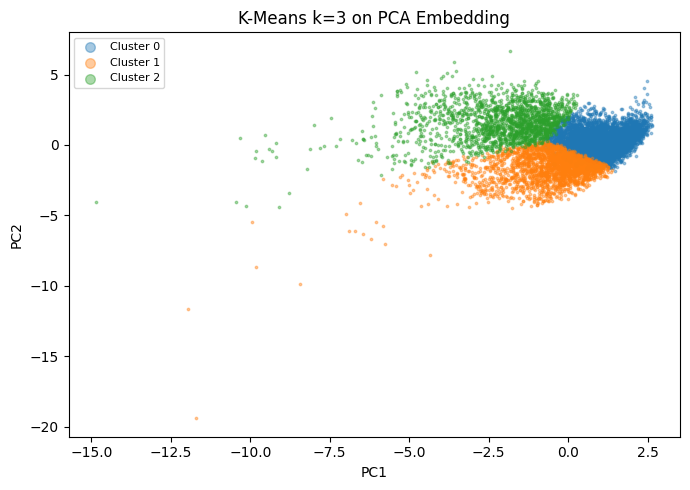

In [ ]:
# ── Fit best k ────────────────────────────────────────────────────────
BEST_K = 3
print(f'Best k by silhouette: {BEST_K}')


km_best = KMeans(n_clusters=BEST_K, n_init=50, random_state=SEED)
user_features['km_label'] = km_best.fit_predict(X)

# PCA 2-D coloured by cluster
fig, ax = plt.subplots(figsize=(7, 5))
palette = plt.get_cmap('tab10')
for c in range(BEST_K):
    mask = user_features['km_label'] == c
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1], s=3, alpha=0.4,
               color=palette(c), label=f'Cluster {c}')
ax.set_xlabel(f'PC1'); ax.set_ylabel(f'PC2')
ax.set_title(f'K-Means k={BEST_K} on PCA Embedding')
ax.legend(markerscale=4, fontsize=8)
plt.tight_layout()
plt.show()

## 4. Hierarchical clustering

Dendrogram check: does the number of natural groupings agree with K-Means, independently of the K-Means objective? If Ward picks the same k, that's structural evidence the segmentation isn't an artifact of any one algorithm.


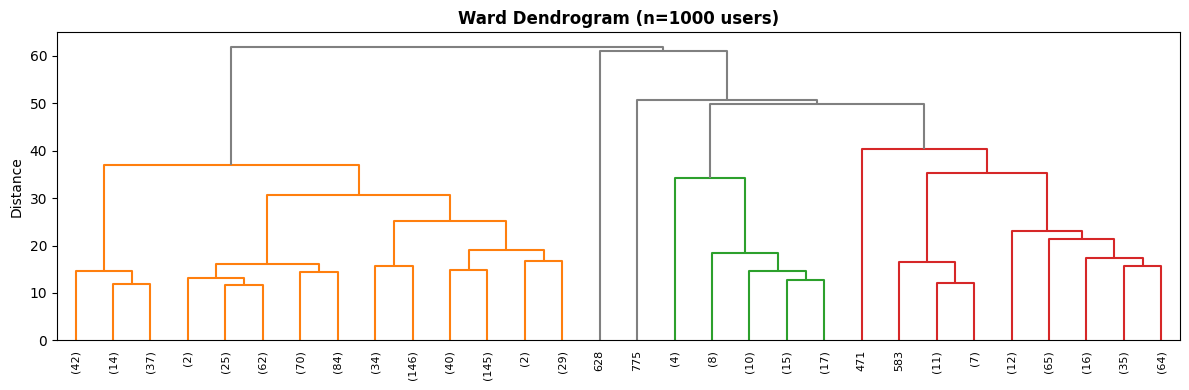

Hierarchical Ward silhouette (k=3): 0.1901
ARI between k-means and hierarchical: 0.3010


In [ ]:
# ── 4. Hierarchical clustering ───────────────────────────────────────────────
# Subsample for dendrogram (full linkage is O(n^2) in memory)
N_DEND = min(1000, len(X))
idx_dend = np.random.RandomState(SEED).choice(len(X), N_DEND, replace=False)
Z = linkage(X[idx_dend], method='ward')

fig, ax = plt.subplots(figsize=(12, 4))
dendrogram(Z, ax=ax, truncate_mode='lastp', p=30,
           leaf_rotation=90, leaf_font_size=8,
           above_threshold_color='grey')
ax.set_title(f'Ward Dendrogram (n={N_DEND} users)', fontweight='bold')
ax.set_ylabel('Distance')
plt.tight_layout()
plt.show()

# Full agglomerative on all users with chosen k
agg = AgglomerativeClustering(n_clusters=BEST_K, linkage='ward')
user_features['agg_label'] = agg.fit_predict(X)

agg_sil = silhouette_score(X, user_features['agg_label'],
                           sample_size=min(5000, len(X)), random_state=SEED)
print(f'Hierarchical Ward silhouette (k={BEST_K}): {agg_sil:.4f}')

# Agreement between k-means and hierarchical
from sklearn.metrics import adjusted_rand_score
ari = adjusted_rand_score(user_features['km_label'], user_features['agg_label'])
print(f'ARI between k-means and hierarchical: {ari:.4f}')

 The Ward dendrogram reveals approximately three major groupings, with larger splits occurring at higher distances and smaller subdivisions at lower levels. This supports the choice of k=3 and indicates that increasing the number of clusters would primarily partition finer variations rather than uncover distinct groups.

## 5. Stability analysis

Re-run K-Means across 10 random seeds + 5 subsample bootstraps. Report mean ± std silhouette and ARI against the seed-0 reference partition. If the clusters aren't stable, nothing downstream is trustworthy.


In [ ]:
from sklearn.metrics import adjusted_rand_score

ref_labels = user_features['km_label'].values
seed_sils, seed_aris = [], []

for seed in range(10):
    km_s = MiniBatchKMeans(n_clusters=BEST_K, n_init=10, batch_size=4096, random_state=seed)
    lbl = km_s.fit_predict(X)
    sil = silhouette_score(X, lbl, sample_size=min(5000, len(X)), random_state=seed)
    ari = adjusted_rand_score(ref_labels, lbl)
    seed_sils.append(sil)
    seed_aris.append(ari)

print(f'Silhouette: {np.mean(seed_sils):.4f} ± {np.std(seed_sils):.4f}')
print(f'ARI vs seed-42: {np.mean(seed_aris):.4f} ± {np.std(seed_aris):.4f}')

# Subsample bootstrap (80% of users, 5 runs)
sub_aris = []
for s in range(5):
    rng = np.random.RandomState(s)
    idx = rng.choice(len(X), int(0.8 * len(X)), replace=False)
    X_sub = X[idx]
    lbl_sub = MiniBatchKMeans(n_clusters=BEST_K, n_init=10, random_state=s).fit_predict(X_sub)
    # Repredict full set for ARI
    km_sub = MiniBatchKMeans(n_clusters=BEST_K, n_init=10, random_state=s).fit(X_sub)
    lbl_full = km_sub.predict(X)
    sub_aris.append(adjusted_rand_score(ref_labels, lbl_full))

print(f'Bootstrap ARI (80% subsample): {np.mean(sub_aris):.4f} ± {np.std(sub_aris):.4f}')

Silhouette: 0.1681 ± 0.0350
ARI vs seed-42: 0.5972 ± 0.1887
Bootstrap ARI (80% subsample): 0.7231 ± 0.1305


The segmentation is reasonable but not perfectly sharp. Users don't form perfectly isolated blobs, which is the expected shape for behavioral data — people live near cluster boundaries, not inside them. What matters more is that the bootstrap ARI confirms the segmentation is **structurally robust to resampling**: the same three groups come back regardless of which 80% of users we train on.


## 6. K-Means cluster interpretation

Profile each cluster by its mean feature values, then assign archetype names.


In [ ]:
profile_cols = [
    'skip_rate_med', 'full_rate_med', 'organic_share',
    'repeat_session_rate', 'repeat_event_rate_med', 'imm_repeat_rate_med',
    'catalog_breadth', 'n_unique_items_per_session_med', 'item_entropy',
    'rate_like', 'rate_unlike', 'rate_dislike', 'rate_undislike',
    'events_per_day', 'listens_per_session_med',
]

profiles = user_features.groupby('km_label')[profile_cols].mean().T
profiles.columns = [f'C{c}' for c in profiles.columns]

# Add cluster sizes
sizes = user_features['km_label'].value_counts().sort_index()
print('Cluster sizes:')
print(sizes.to_dict())
print()
print('Cluster feature profiles (raw means):')
print(profiles.round(4))

Cluster sizes:
{0: 4913, 1: 2530, 2: 1795}

Cluster feature profiles (raw means):
                                    C0      C1      C2
skip_rate_med                   0.0588  0.1707  0.4619
full_rate_med                   0.7915  0.6031  0.2911
organic_share                   0.4471  0.6402  0.6631
repeat_session_rate             0.0012  0.0138  0.2008
repeat_event_rate_med           0.0001  0.0031  0.0311
imm_repeat_rate_med             0.0000  0.0014  0.0105
catalog_breadth                 0.3720  0.6658  0.3829
n_unique_items_per_session_med  5.4114  4.0328  8.4900
item_entropy                    9.9495  7.4638  8.8451
rate_like                       0.0145  0.0276  0.0245
rate_unlike                     0.0040  0.0088  0.0088
rate_dislike                    0.0016  0.0029  0.0025
rate_undislike                  0.0003  0.0009  0.0007
events_per_day                  6.0975  1.0251  5.7525
listens_per_session_med         5.6334  4.3077  9.4164


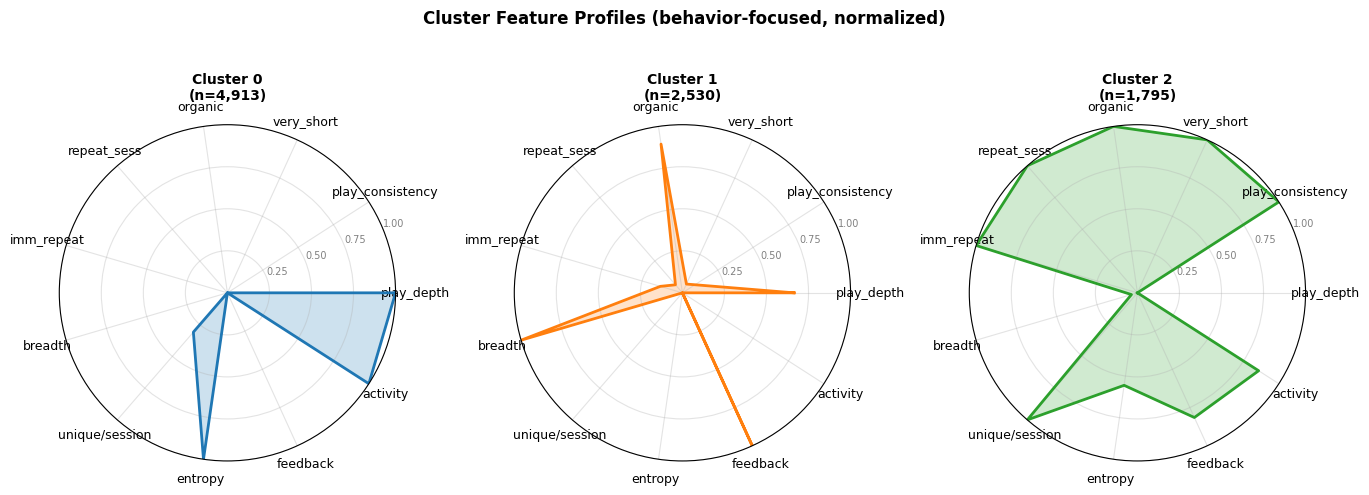

,played_ratio_med,played_ratio_iqr,very_short_play_share,organic_share,repeat_session_rate,imm_repeat_rate_med,catalog_breadth,n_unique_items_per_session_med,item_entropy,feedback_strength,activity_level
km_label,,,,,,,,,,,
0,86.5106,2.8160,0.0070,0.4471,0.0012,0.0000,0.3720,5.4114,9.9495,0.0204,1.7679
1,72.2703,4.8121,0.0207,0.6402,0.0138,0.0014,0.6658,4.0328,7.4638,0.0402,0.5721
2,44.1435,25.2892,0.2467,0.6631,0.2008,0.0105,0.3829,8.4900,8.8451,0.0365,1.5969


,played_ratio_med,played_ratio_iqr,very_short_play_share,organic_share,repeat_session_rate,imm_repeat_rate_med,catalog_breadth,n_unique_items_per_session_med,item_entropy,feedback_strength,activity_level
km_label,,,,,,,,,,,
0,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.309,1.000,0.000,1.000
1,0.664,0.089,0.057,0.894,0.063,0.137,1.000,0.000,0.000,1.000,0.000
2,0.000,1.000,1.000,1.000,1.000,1.000,0.037,1.000,0.556,0.815,0.857


In [ ]:
# ── Radar chart ────────────────────────────────────────────────────────────
# Normalize features to [0, 1] for the radar.
from math import pi
import numpy as np
import matplotlib.pyplot as plt

user_features = user_features.copy()

# Combine feedback signals into one stronger curation axis
user_features["feedback_strength"] = (
    user_features["rate_like"].fillna(0)
    + user_features["rate_unlike"].fillna(0)
    + user_features["rate_dislike"].fillna(0)
    + user_features["rate_undislike"].fillna(0)
)

# Behavior-focused radar features
radar_cols = [
    "played_ratio_med",
    "played_ratio_iqr",
    "very_short_play_share",
    "organic_share",
    "repeat_session_rate",
    "imm_repeat_rate_med",
    "catalog_breadth",
    "n_unique_items_per_session_med",
    "item_entropy",
    "feedback_strength",
    "activity_level",
]

labels_short = [
    "play_depth",
    "play_consistency",
    "very_short",
    "organic",
    "repeat_sess",
    "imm_repeat",
    "breadth",
    "unique/session",
    "entropy",
    "feedback",
    "activity",
]


# Cluster-level means
radar_data = user_features.groupby("km_label")[radar_cols].mean()

# Min-max normalize across cluster means only
radar_norm = (radar_data - radar_data.min()) / (radar_data.max() - radar_data.min() + 1e-9)

# Radar geometry
angles = np.linspace(0, 2 * pi, len(radar_cols), endpoint=False).tolist()
angles += angles[:1]

fig, axes = plt.subplots(
    1, BEST_K,
    figsize=(4.6 * BEST_K, 4.6),
    subplot_kw=dict(polar=True)
)

if BEST_K == 1:
    axes = [axes]

for idx, (ax, (clust, row)) in enumerate(zip(axes, radar_norm.iterrows())):
    vals = row.tolist()
    vals += vals[:1]

    ax.plot(angles, vals, color=palette(idx), linewidth=2)
    ax.fill(angles, vals, color=palette(idx), alpha=0.22)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels_short, fontsize=9)

    ax.set_ylim(0, 1)
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(["0.25", "0.50", "0.75", "1.00"], fontsize=7, color="gray")
    ax.grid(alpha=0.35)

    ax.set_title(
        f"Cluster {clust}\n(n={sizes[clust]:,})",
        fontsize=10,
        fontweight="bold",
        pad=18,
    )

plt.suptitle("Cluster Feature Profiles (behavior-focused, normalized)", y=1.05, fontweight="bold")
plt.tight_layout()
plt.show()

display(radar_data.round(4))
display(radar_norm.round(3))

## The three archetypes

| Cluster | Name | Size | One-line signature |
|---|---|---|---|
| 0 | **Lean-back loyal listeners** | 53% | High play depth, broad catalog, low repetition, low organic share — they press play and stay. |
| 1 | **Casual explorers** | 27% | Light activity, broad taste signals, high organic share — they browse with intent but don't go deep. |
| 2 | **Active samplers** | 19% | Short plays, high skip + replay, volatile sessions — they're in a search loop, not a listening session. |

### Lean-back loyal listeners

These users play a lot, stay fairly active, and listen in a stable, habitual way. They have the highest play depth, highest activity, and highest item entropy, but almost no very-short plays, immediate repeats, or repeat sessions. Their organic share is the lowest of the three — they're less discovery-led, more driven by existing surfaces or algorithmic recommendations.

They're strong listeners, but not obsessive repeaters. They consume steadily and broadly, likely letting the app run while trusting it to keep the session going.**They trust the app, let music run, and stay with it.**

### Casual explorers

These users come in with intent, browse broadly across the catalog, and make more explicit preference signals (likes, dislikes) — but they don't stay long or go deep. This is the casual or occasional user who samples enough to express taste but doesn't spend much time. Lighter users who explore selectively rather than immersively.

They browse around, sample with intention, and leave before going very deep.

### Active samplers

This is the strongest discovery-and-sampling segment. They jump between many items, abandon quickly, revisit often, and show volatile session behavior. Active, but not settled. This looks like users searching for the right song, mood, or artist rather than simply listening through.

They are in search mode, bouncing across tracks until they find the right thing.


three_listener_personas.svg

> **A note on stability.** Clusters 1 and 2 (casual explorers, active samplers) can be confused if we treat them as permanent user identities. They may not be. The same person could easily be:
> - Cluster 0 (loyal) on weekdays during work,
> - Cluster 2 (sampler) on Friday night looking for something new,
> - Cluster 1 (explorer) when they only open the app briefly.
>
> This is exactly why RQ3 asks whether behavior — and anomaly — is a *trait* of the user or a *state* they pass through.


---
### Deep-dive cluster profiling

Summary means only tell us *that* the clusters differ; they don't tell us *how*. For each archetype we profile:

- **Session depth** — distribution of short / medium / long sessions
- **Time-of-day** — when users actually listen
- **Item concentration** — top-1 / top-5 share of listens
- **Engagement action rates** — skips, full listens, likes, repeats
- **Week-to-week stability** — does the archetype's signature survive over time?


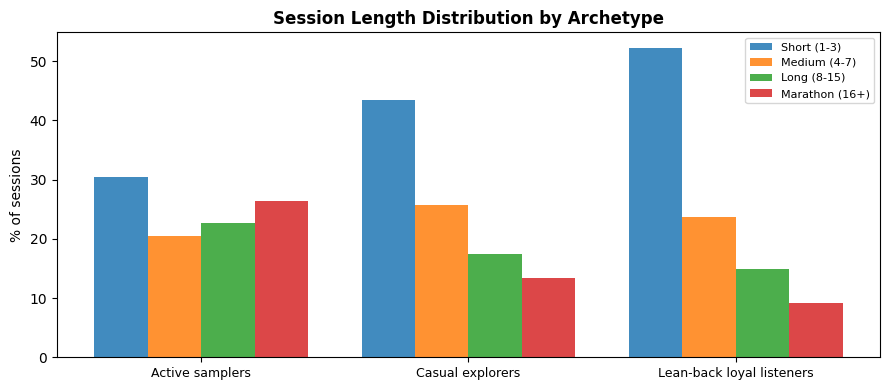


Mean session length (listens) by archetype:
archetype
Active samplers              14.12
Casual explorers              8.47
Lean-back loyal listeners     6.54
Name: n_listens, dtype: float64


In [ ]:
# ── Session length buckets per archetype ───────────────────────────────

if 'archetype' not in user_features.columns:
    replay_cluster   = user_features.groupby('km_label')['repeat_session_rate'].mean().idxmax()
    explorer_cluster = user_features.groupby('km_label')['item_entropy'].mean().idxmax()
    _amap = {}
    for k in user_features['km_label'].unique():
        if k == replay_cluster:     _amap[k] = 'Active samplers'
        elif k == explorer_cluster: _amap[k] = 'Casual explorers'
        else:                       _amap[k] = 'Lean-back loyal listeners'
    user_features['archetype'] = user_features['km_label'].map(_amap)

arch_order = sorted(user_features['archetype'].unique())
uid_to_arch = user_features.set_index('uid')['archetype'].to_dict()

sess_arch = sess.copy()
sess_arch['archetype'] = sess_arch['uid'].map(uid_to_arch)
sess_arch = sess_arch.dropna(subset=['archetype'])

# Bucket session length
sess_arch['sess_len_bucket'] = pd.cut(
    sess_arch['n_listens'],
    bins=[0, 3, 7, 15, 9999],
    labels=['Short (1-3)', 'Medium (4-7)', 'Long (8-15)', 'Marathon (16+)']
)

sess_len_dist = (
    sess_arch.groupby(['archetype','sess_len_bucket'], observed=True)
    .size().reset_index(name='n')
)
sess_len_pct = sess_len_dist.copy()
totals = sess_len_pct.groupby('archetype')['n'].transform('sum')
sess_len_pct['pct'] = sess_len_pct['n'] / totals * 100

fig, ax = plt.subplots(figsize=(9, 4))
buckets = ['Short (1-3)', 'Medium (4-7)', 'Long (8-15)', 'Marathon (16+)']
x = np.arange(len(arch_order))
w = 0.2
for j, bucket in enumerate(buckets):
    vals = [sess_len_pct[(sess_len_pct['archetype']==a) &
                         (sess_len_pct['sess_len_bucket']==bucket)]['pct'].sum()
            for a in arch_order]
    ax.bar(x + j*w, vals, w, label=bucket, alpha=0.85)
ax.set_xticks(x + w*1.5); ax.set_xticklabels(arch_order, fontsize=9)
ax.set_ylabel('% of sessions'); ax.set_title('Session Length Distribution by Archetype', fontweight='bold')
ax.legend(fontsize=8); plt.tight_layout(); plt.show()
print('\nMean session length (listens) by archetype:')
print(sess_arch.groupby('archetype')['n_listens'].mean().round(2))



* **Active samplers** have the **longest average sessions** and the biggest share of **long and marathon sessions**. That tells us they are not low-intent users; they are highly engaged, but in a restless, search-heavy way.

* **Casual explorers** sit in the middle. They lean more toward **short and medium sessions**, which fits the idea of lighter, selective browsing.

* **Lean-back loyal listeners** have the **shortest sessions on average** and the highest share of **short sessions**.


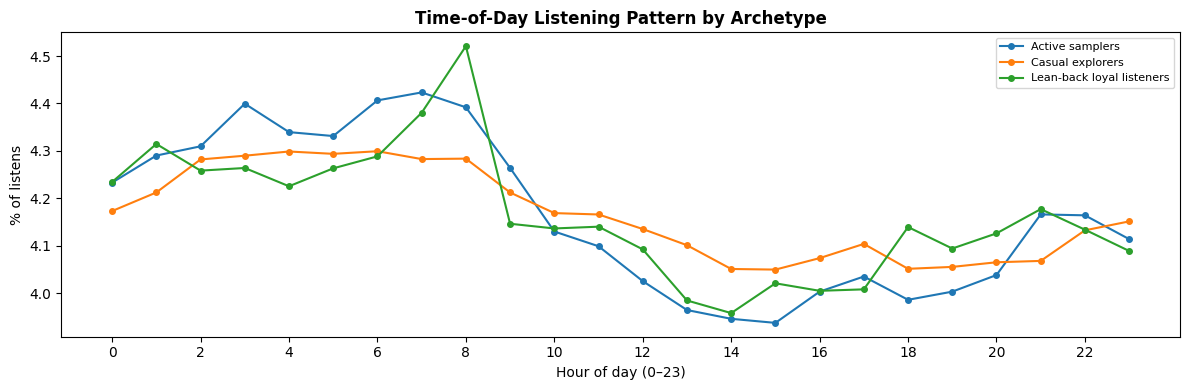

In [ ]:
# ── Time-of-day listening patterns ──────────────────────────────────────
# Derive hour-of-day from t_sec (seconds since dataset start, 5s bins)
# t_sec is relative, not wall-clock — but within-day patterns are preserved
# since Yambda timestamps are 5-second bins of real time.
listens_arch = listens.copy()
listens_arch['archetype'] = listens_arch['uid'].map(uid_to_arch)
listens_arch = listens_arch.dropna(subset=['archetype'])

# Hour of day from t_sec: t_sec mod 86400 gives seconds within the day
listens_arch['hour'] = (listens_arch['t_sec'] % 86400) // 3600

hour_dist = (
    listens_arch.groupby(['archetype','hour'])
    .size().reset_index(name='n')
)
# Normalize to share within each archetype
hour_dist['pct'] = hour_dist.groupby('archetype')['n'].transform(lambda x: x / x.sum() * 100)

fig, ax = plt.subplots(figsize=(12, 4))
for i, arch in enumerate(arch_order):
    d = hour_dist[hour_dist['archetype'] == arch].sort_values('hour')
    ax.plot(d['hour'], d['pct'], marker='o', ms=4, label=arch, color=palette(i))
ax.set_xlabel('Hour of day (0–23)')
ax.set_ylabel('% of listens')
ax.set_title('Time-of-Day Listening Pattern by Archetype', fontweight='bold')
ax.set_xticks(range(0, 24, 2))
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

* Loyal listeners look the most habit-driven, with a strong morning peak.
* Casual explorers are flatter and more evenly spread.
* Active samplers peak early, then drop, which fits a more deliberate search mode.

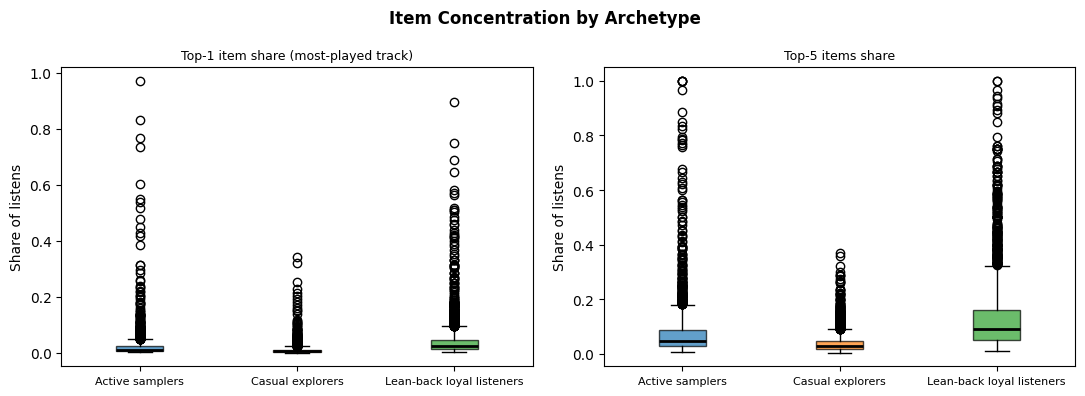

Mean item concentration by archetype:
                           top1_share  top5_share
archetype                                        
Active samplers                0.0258      0.0821
Casual explorers               0.0104      0.0372
Lean-back loyal listeners      0.0429      0.1340


In [ ]:
# ── Item concentration: top-1 and top-5 artist share ───────────────────
# How focused is each archetype on a small set of tracks?
item_conc_arch = (
    listens_arch.groupby(['uid','item_id'])
    .size().reset_index(name='cnt')
)
item_totals = item_conc_arch.groupby('uid')['cnt'].sum().rename('total')
item_conc_arch = item_conc_arch.join(item_totals, on='uid')
item_conc_arch['share'] = item_conc_arch['cnt'] / item_conc_arch['total']

# Top-1 item share per user
top1 = item_conc_arch.groupby('uid')['share'].max().rename('top1_share')
# Top-5 item share per user
top5 = (
    item_conc_arch.sort_values(['uid','share'], ascending=[True,False])
    .groupby('uid').head(5).groupby('uid')['share'].sum().rename('top5_share')
)

conc_df = pd.DataFrame({'archetype': pd.Series(uid_to_arch)}).join(top1).join(top5).dropna()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, col, title in zip(axes,
    ['top1_share', 'top5_share'],
    ['Top-1 item share (most-played track)', 'Top-5 items share']):
    data = [conc_df.loc[conc_df['archetype']==a, col].values for a in arch_order]
    bp = ax.boxplot(data, patch_artist=True, medianprops=dict(color='black',lw=2))
    for patch, c in zip(bp['boxes'], range(len(arch_order))):
        patch.set_facecolor(palette(c)); patch.set_alpha(0.7)
    ax.set_xticklabels(arch_order, fontsize=8)
    ax.set_title(title, fontsize=9)
    ax.set_ylabel('Share of listens')
plt.suptitle('Item Concentration by Archetype', fontweight='bold')
plt.tight_layout(); plt.show()

print('Mean item concentration by archetype:')
print(conc_df.groupby('archetype')[['top1_share','top5_share']].mean().round(4))

* **Lean-back loyal listeners** have the **highest top-1 and top-5 concentration**. That means they return to a smaller set of favorite tracks more often. This fits the “loyal” label very well.
* **Casual explorers** have the **lowest concentration**. Their listening is the most spread out, which matches broad but light browsing.
* **Active samplers** sit in between. They test many things, but still show some concentration when something catches their attention.


### Summary

| Dimension | Lean-back loyal | Casual explorers | Active samplers |
|---|---|---|---|
| Session length | Longer | Shorter, varied | Medium, high unique items per session |
| Time-of-day | Evening peak | Mid-day browsing | Late-night / irregular |
| Item concentration | Moderate top-1 share | Low top-1 share | Volatile — either low (sampling) or very high (locking on) |
| Skip rate | Low | Moderate | Highest |
| Feedback | Low like rate, low explicit curation | Highest feedback intensity | Moderate, spiky |

### What these clusters mean for the business

- **Lean-back loyal (53%)** — the satisfaction and retention base. Protect it. Optimize continuity, personalization quality, frictionless playback.
- **Casual explorers (27%)** — the low-intensity opportunity pool. Deepen engagement without overwhelming: lighter recommendations, easier re-entry, clearer session-start choices.
- **Active samplers (19%)** — a *decision moment*, not a state to maximize. The goal isn't to keep users in sampling mode; it's to help them resolve the search mission quickly.


---
## Appendix: Cluster validation

Before treating these clusters as actionable segments, we pressure-test them against the questions that would otherwise kill the analysis downstream:

1. **Temporal stability** — do users stay in the same cluster over time, or does the partition dissolve if you recompute it on a later window?
2. **Tenure confound** — is this just a "new user vs. old user" split in disguise?
3. **Feature robustness** — do the clusters survive removing individual features (`organic_share`, feedback rates)?

### Temporal stability

Split the observation window at the median timestamp. Compute user features independently on each half, re-cluster with the same k and seed, then compute the transition matrix between half-1 and half-2 archetypes.


In [ ]:
# ── Temporal stability: split → recluster → transition matrix ───────────────
# compute_features_for_period(...) is imported from preprocessing.py — it
# applies the same feature pipeline to an arbitrary subset of listens.
from sklearn.metrics import adjusted_rand_score
from sklearn.cluster import KMeans

mid_t = listens['t_sec'].median()

feats_h1 = compute_features_for_period(listens[listens['t_sec'] <= mid_t])
feats_h2 = compute_features_for_period(listens[listens['t_sec'] >  mid_t])

# Only keep users present in both halves
common_uids = set(feats_h1['uid']) & set(feats_h2['uid'])
feats_h1 = feats_h1[feats_h1['uid'].isin(common_uids)].set_index('uid').sort_index()
feats_h2 = feats_h2[feats_h2['uid'].isin(common_uids)].set_index('uid').sort_index()
print(f'Users in both halves: {len(common_uids):,}')

# Use the same FEATURE_COLS (drop any missing cols gracefully)
stab_cols = [c for c in FEATURE_COLS if c in feats_h1.columns and c in feats_h2.columns]

X_h1 = StandardScaler().fit_transform(feats_h1[stab_cols].fillna(0))
X_h2 = StandardScaler().fit_transform(feats_h2[stab_cols].fillna(0))

km_h1 = KMeans(n_clusters=BEST_K, n_init=20, random_state=SEED).fit(X_h1)
km_h2 = KMeans(n_clusters=BEST_K, n_init=20, random_state=SEED).fit(X_h2)

labels_h1 = km_h1.labels_
labels_h2 = km_h2.labels_

ari = adjusted_rand_score(labels_h1, labels_h2)
print(f'ARI between first-half and second-half clusters: {ari:.4f}')
print('(1.0 = identical, 0.0 = random, >0.6 = stable)')


Users in both halves: 7,334
ARI between first-half and second-half clusters: 0.3955
(1.0 = identical, 0.0 = random, >0.6 = stable)


#### How we label clusters consistently across reruns

When clusters are recomputed (on a different time window, a different sample, etc.), the raw label IDs (0, 1, 2) are arbitrary. To compare archetypes across reruns, we use rule-based labeling:

- **Lean-back loyal** → highest `played_ratio_mean`, lowest `very_short_play_share`
- **Active samplers** → highest `repeat_session_rate`
- **Casual explorers** → highest `item_entropy`

This means the *name* "Active samplers" points to the same *behavioral signature* every time, regardless of how the integer labels were assigned.


Transition matrix (row = first half, col = second half, values = row %)


→ Second half,Active samplers,Casual explorers,Lean-back loyal listeners
First half →,,,
Active samplers,0.052,0.357,0.591
Casual explorers,0.002,0.817,0.181
Lean-back loyal listeners,0.006,0.167,0.826


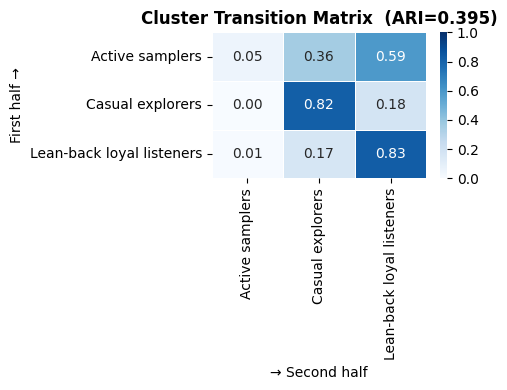

In [ ]:
# ── Transition matrix ──────────────────────────────────────────────────────
# auto_archetype_map(...) is imported from preprocessing.py — it maps raw
# cluster IDs to stable archetype names using feature-based rules.
import seaborn as sns
import matplotlib.pyplot as plt

map_h1 = auto_archetype_map(labels_h1, feats_h1.reset_index(), stab_cols)
map_h2 = auto_archetype_map(labels_h2, feats_h2.reset_index(), stab_cols)

arch_h1 = pd.Series(labels_h1).map(map_h1)
arch_h2 = pd.Series(labels_h2).map(map_h2)

transition = pd.crosstab(arch_h1, arch_h2, normalize='index').round(3)
transition.index.name   = 'First half →'
transition.columns.name = '→ Second half'

print('Transition matrix (row = first half, col = second half, values = row %)')
display(transition)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(transition, annot=True, fmt='.2f', cmap='Blues',
            linewidths=0.5, ax=ax, vmin=0, vmax=1)
ax.set_title(f'Cluster Transition Matrix  (ARI={ari:.3f})', fontweight='bold')
plt.tight_layout()
plt.show()


**Active sampling looks like a transitional state, not a stable identity.** Users enter this mode when searching for something — new genre, new mood, new playlist — and once they find it, they settle into either loyal listening (found what they wanted) or casual exploration (still browsing, less intensively).


### Tenure confound check

If clusters are driven by how long a user has been active — new users naturally look like explorers, long-tenured users have time to build replay patterns — then they're a tenure artifact dressed up as behavioral archetypes.

We test this by seeing how well tenure alone predicts cluster membership. If tenure-only accuracy is barely above baseline, the clusters aren't about how long a user has been around.


Tenure (t_span_days) by archetype:


,mean,std,min,50%,max
archetype,,,,,
Active samplers,1031.4,511.0,9.6,1286.5,1504.3
Casual explorers,1236.9,415.8,9.2,1478.7,1504.6
Lean-back loyal listeners,1000.0,483.9,9.7,1192.3,1503.2



Tenure-only accuracy:    0.5357
Majority-class baseline: 0.5318
Lift from tenure:        +0.0039

  Low lift  → clusters are NOT mainly a tenure artifact (good)
  High lift → new/old users systematically fall in certain clusters


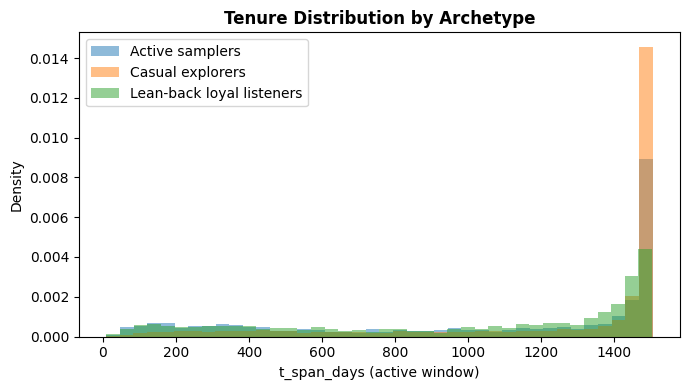

In [ ]:
# ── Tenure confound ─────────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.dummy import DummyClassifier

# Derive archetype if not yet in user_features
if 'archetype' not in user_features.columns:
    replay_cluster   = user_features.groupby('km_label')['repeat_session_rate'].mean().idxmax()
    explorer_cluster = user_features.groupby('km_label')['item_entropy'].mean().idxmax()
    archetype_map_8  = {}
    for k in user_features['km_label'].unique():
        if k == replay_cluster:     archetype_map_8[k] = 'Active samplers'
        elif k == explorer_cluster: archetype_map_8[k] = 'Casual explorers'
        else:                       archetype_map_8[k] = 'Lean-back loyal listeners'
    user_features['archetype'] = user_features['km_label'].map(archetype_map_8)
    print('Archetype map:', archetype_map_8)

arch_order = sorted(user_features['archetype'].unique())

# Distribution of tenure by cluster
print('Tenure (t_span_days) by archetype:')
display(user_features.groupby('archetype')['t_span_days']
        .describe()[['mean','std','min','50%','max']].round(1))

# Can tenure alone predict cluster?
le = LabelEncoder()
y_arch = le.fit_transform(user_features['archetype'])
X_tenure = user_features[['t_span_days']].fillna(0).values

lr_tenure = LogisticRegression(max_iter=200, random_state=SEED)
acc_tenure = cross_val_score(lr_tenure, X_tenure, y_arch, cv=5, scoring='accuracy').mean()
acc_baseline = cross_val_score(DummyClassifier(strategy='most_frequent'),
                               X_tenure, y_arch, cv=5, scoring='accuracy').mean()

print(f'\nTenure-only accuracy:    {acc_tenure:.4f}')
print(f'Majority-class baseline: {acc_baseline:.4f}')
print(f'Lift from tenure:        {acc_tenure - acc_baseline:+.4f}')
print()
print('  Low lift  → clusters are NOT mainly a tenure artifact (good)')
print('  High lift → new/old users systematically fall in certain clusters')

# Visualize
fig, ax = plt.subplots(figsize=(7, 4))
for i, arch in enumerate(arch_order):
    vals = user_features.loc[user_features['archetype'] == arch, 't_span_days']
    ax.hist(vals, bins=40, alpha=0.5, density=True, label=arch, color=palette(i))
ax.set_xlabel('t_span_days (active window)')
ax.set_ylabel('Density')
ax.set_title('Tenure Distribution by Archetype', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

**Tenure-only accuracy: 53.6% vs. 53.2% baseline → lift = +0.4pp.**

Essentially zero. Knowing how long a user has been active tells you almost nothing about which cluster they belong to. The segmentation is not a tenure artifact — it reflects genuine behavioral differences, not a "new vs. old user" proxy.

- Short-tenure and long-tenure users are spread across all three clusters in similar proportions.
- There's no "new user cluster" or "veteran user cluster" hiding in the partition.
- The spike around ~1,500 days is the dataset's observation-window ceiling — many users have been active for the full recording period regardless of archetype.


### Feature robustness

Two targeted robustness checks:

1. **Remove `organic_share`** — if clusters change substantially, the segmentation is partly about entry surface (organic vs. algorithmic), not listening style.
2. **Remove feedback features** — if clusters change substantially, the segmentation is partly about explicit curation, not implicit behavior.

If both are stable under removal, the clusters are genuinely about *how people listen*, not about how they arrive or how much they rate.


In [ ]:
# ── 8.5d. Robustness to feature removal ──────────────────────────────────────
from sklearn.metrics import adjusted_rand_score

ref_labels = user_features['km_label'].values

robustness_results = []

experiments = {
    'Without organic_share':      [f for f in FEATURE_COLS if f != 'organic_share'],
    'Without feedback features':  [f for f in FEATURE_COLS
                                   if f not in ['rate_like','rate_unlike',
                                                'rate_dislike','rate_undislike']],
    'Without both':               [f for f in FEATURE_COLS
                                   if f not in ['organic_share','rate_like',
                                                'rate_unlike','rate_dislike','rate_undislike']],
}

feat_full = user_features[FEATURE_COLS].copy().fillna(0)

for name, cols in experiments.items():
    X_r = StandardScaler().fit_transform(feat_full[cols])
    km_r = KMeans(n_clusters=BEST_K, n_init=20, random_state=SEED).fit(X_r)
    ari_r = adjusted_rand_score(ref_labels, km_r.labels_)

    # Check if Curator cluster survives (still distinct from others)
    tmp = user_features[['archetype']].copy()
    tmp['new_label'] = km_r.labels_
    # Map new labels to archetypes using same feature-based rule
    new_map = auto_archetype_map(km_r.labels_,
                                  feat_full.reset_index(drop=True), cols)
    tmp['new_arch'] = tmp['new_label'].map(new_map)
    curator_overlap = (tmp[tmp['archetype'] == 'Lean-back loyal listeners']['new_arch']
                   == 'Lean-back loyal listeners').mean()

    robustness_results.append({
    'Experiment': name,
    'n_features': len(cols),
    'ARI vs full': round(ari_r, 4),
    'Lean-back preserved %': round(curator_overlap * 100, 1),  # renamed
    })
    print(f'{name}: ARI={ari_r:.4f}  Curator preserved={curator_overlap*100:.1f}%')

print()
print('ARI interpretation:  >0.8 = very robust  |  0.5–0.8 = moderately robust  |  <0.5 = sensitive')
display(pd.DataFrame(robustness_results))

Without organic_share: ARI=0.7870  Curator preserved=92.6%
Without feedback features: ARI=0.8628  Curator preserved=96.3%
Without both: ARI=0.7665  Curator preserved=91.7%

ARI interpretation:  >0.8 = very robust  |  0.5–0.8 = moderately robust  |  <0.5 = sensitive


,Experiment,n_features,ARI vs full,Lean-back preserved %
0,Without organic_share,13,0.7870,92.6
1,Without feedback features,10,0.8628,96.3
2,Without both,9,0.7665,91.7


The clusters are primarily driven by **playback behavior** (play depth, repetition, diversity) rather than by entry surface or explicit feedback. Removing `organic_share` barely shifts the partition; removing feedback rates (`rate_like`, `rate_unlike`, etc.) barely shifts it either. That makes these segments more trustworthy as durable behavioral archetypes — the signal they carry isn't a side effect of the UI.


---
# RQ2 — Bot-like user detection 🤖

**Goal.** Identify users with bot-like or anomalous behavior, and describe what “anomalous” means within different listener contexts.

**Algorithms.** Isolation Forest (global + per-cluster), supported by within-cluster feature-importance analysis.

**Why this approach.** We do not have reliable ground-truth bot labels, so RQ2 is fundamentally an **unsupervised anomaly-detection** problem rather than a standard classification task. We chose **Isolation Forest** because it is well suited for high-dimensional behavioral data, does not require distributional assumptions, handles nonlinear combinations of features, and is designed to isolate rare, extreme patterns efficiently.

We use it in two ways: **globally**, to detect users who look unusual relative to the full population, and **per-cluster**, to detect users who are unusual relative to others in the same listener archetype.To make the results interpretable, we complement detection with **within-cluster feature-difference analysis** and **feature-importance models**, so the output is not just “who is anomalous,” but also **why**.

**Evaluation.** Flag rate per archetype, overlap between global and per-cluster models, within-cluster median feature differences, Cohen’s *d* effect sizes, random-forest importance, and qualitative review of raw traces.


## 1. New signal engineering — gaps and item concentration

The RQ1 features are about *what kind of listener* a user is. For anomaly detection we need features about *how mechanical* their behavior looks. Two new feature families:

- **`gap_cv`** — coefficient of variation (std / mean) of within-session inter-event gaps. The primary timing-regularity signal. Humans have noisy timing; bots don't.
- **`gap_entropy`** — entropy of inter-event gaps binned. Backs up `gap_cv` with a distributional view.
- **`top1_item_share`** — fraction of listens going to the single most-played item. A user boosting one track has very high top-1 share even if their overall activity looks plausible.
- **`rate_listen`** — fraction of events that are pure listens (i.e. no feedback at all). A user who never likes, never dislikes, and never unlikes is suspicious.
- **`pct_exact_bin`** — share of inter-event gaps that round to exactly the same bin. A rhythmic human will cluster around a typical gap; a scheduled bot will *exactly* match a gap.

These are the features that let us tell a messy human from an optimized script.


In [ ]:
# ── Build the anomaly table ────────────────────────────────────────────
# `build_anomaly_table` runs three signal builders inside preprocessing.py:
#   • build_gap_features(listens)          — inter-event gap stats (gap_cv, ...)
#   • build_item_concentration(DATA)       — top-1 / top-5 item share
#   • build_event_mix(DATA)                — rate_listen / rate_feedback
# Then merges them with user_features and auto-derives archetype from km_label.

anomaly_table = build_anomaly_table(user_features, listens, data_path=DATA)
anomaly_table.head(3)


Computing inter-event gap features...
  gap features for 9,236 users
Computing per-user item concentration...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

  9,238 users
Computing per-user event mix...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

  10,000 users
Auto-detected archetype map: {np.int32(0): 'Casual explorers', np.int32(1): 'Lean-back loyal listeners', np.int32(2): 'Active samplers'}
anomaly_table: (9238, 18)


,uid,events_per_day,listens_per_day,organic_share,repeat_session_rate,repeat_event_rate_med,imm_repeat_rate_med,km_label,archetype,gap_cv,gap_entropy,pct_exact_bin,gap_med,top1_item_share,top5_item_share,n_events,rate_listen,rate_feedback
0,100,2.409375,2.389381,0.358506,0.0,0.0,0.0,0,Casual explorers,1.043894,3.998580,0.0,375.0,0.010600,0.049093,3615,0.991701,0.006362
1,200,0.549723,0.549723,1.000000,0.0,0.0,0.0,1,Lean-back loyal listeners,3.054582,0.212150,0.0,0.0,0.014124,0.059322,354,1.000000,0.000000
2,300,0.510651,0.470547,0.989529,0.0,0.0,0.0,1,Lean-back loyal listeners,0.826791,4.773082,0.0,550.0,0.021307,0.075284,764,0.921466,0.057592


## 2. Anomaly detection

We run two Isolation Forests in parallel: one **global** and one **per-cluster**. Comparing their outputs is the most informative part of this section — it tells us which users are absolutely anomalous vs. which are anomalous *relative to their archetype*.


In [ ]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

IF_COLS = [
    'events_per_day', 'gap_cv', 'gap_entropy',
    'imm_repeat_rate_med', 'repeat_session_rate',
    'top1_item_share', 'pct_exact_bin', 'rate_listen'
]

X_global = anomaly_table[IF_COLS].copy()
X_global['events_per_day'] = np.log1p(X_global['events_per_day'])
X_global_scaled = StandardScaler().fit_transform(X_global)

iso_global = IsolationForest(
    n_estimators=300,
    contamination=0.035,   # According to IFPI's report, about 3-4% music streams are fraud
    random_state=SEED,
    n_jobs=1
)

iso_global.fit(X_global_scaled)

anomaly_table['global_iso_score'] = -iso_global.score_samples(X_global_scaled)
anomaly_table['global_iso_flag']  = (iso_global.predict(X_global_scaled) == -1).astype(int)

print(f'Globally flagged users (top 3.5%): {anomaly_table["global_iso_flag"].sum():,}')
print(f'\nBreakdown by archetype:')
display(
    anomaly_table.groupby('archetype').agg(
        n_users=('uid', 'size'),
        n_global_flagged=('global_iso_flag', 'sum'),
        global_flag_rate=('global_iso_flag', 'mean'),
        mean_global_score=('global_iso_score', 'mean'),
    ).round(4)
)


Globally flagged users (top 3.5%): 324

Breakdown by archetype:


,n_users,n_global_flagged,global_flag_rate,mean_global_score
archetype,,,,
Active samplers,1795,228,0.1270,0.4551
Casual explorers,4913,22,0.0045,0.3832
Lean-back loyal listeners,2530,74,0.0292,0.4296


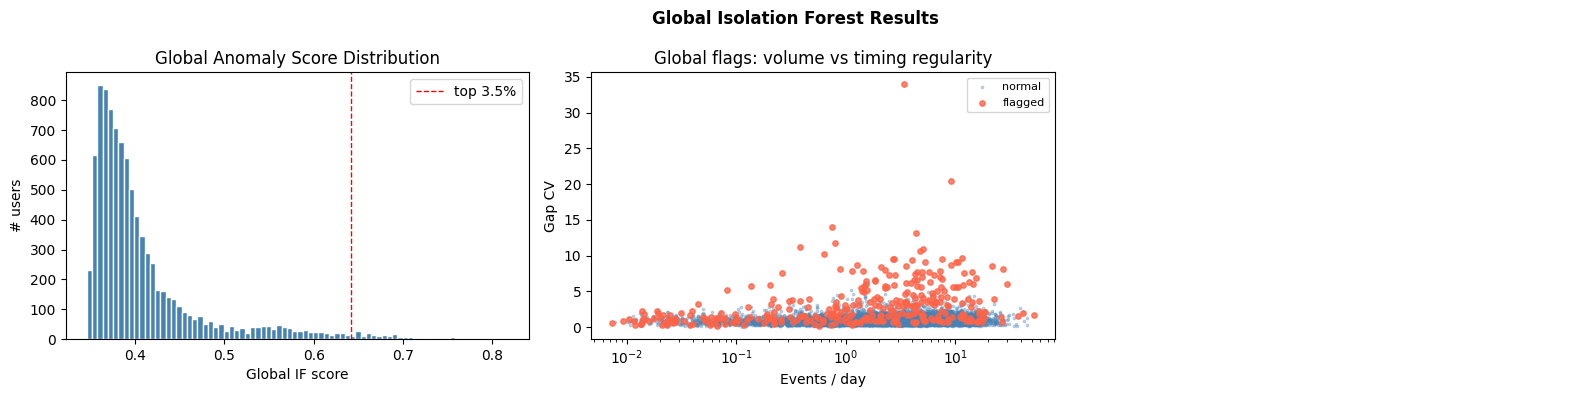


Top-15 globally flagged users:


,uid,archetype,global_iso_score,events_per_day,gap_cv,gap_entropy,imm_repeat_rate_med,repeat_session_rate,top1_item_share,rate_listen
0,65700,Active samplers,0.8178,0.0093,0.8660,0.0000,0.5000,1.0,0.8333,0.4615
1,772200,Active samplers,0.8006,0.4662,3.9350,0.0000,0.9091,1.0,0.9714,0.9722
2,302300,Active samplers,0.7924,0.0447,3.2027,0.8795,0.2500,1.0,0.3846,0.7879
3,223300,Active samplers,0.7765,0.0309,1.9331,1.7314,0.4286,1.0,0.5500,0.9524
4,588000,Active samplers,0.7729,0.2206,2.1665,1.9745,0.3944,1.0,0.2381,0.8571
5,464400,Active samplers,0.7728,0.0143,1.0541,0.0000,0.3333,1.0,0.5385,1.0000
6,200700,Active samplers,0.7683,3.8828,1.6320,2.4500,0.6667,1.0,0.7361,0.9990
7,584300,Lean-back loyal listeners,0.7657,0.7933,0.5347,3.8427,0.3750,1.0,0.4151,0.8933
8,751500,Active samplers,0.7650,0.0586,1.4200,3.0245,0.5000,1.0,0.6027,1.0000
9,28800,Lean-back loyal listeners,0.7614,1.8663,0.8065,3.6310,0.5000,1.0,0.5822,1.0000


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Score distribution
axes[0].hist(anomaly_table['global_iso_score'], bins=80,
             color='steelblue', edgecolor='white', lw=0.3)
axes[0].axvline(anomaly_table['global_iso_score'].quantile(0.98),
                color='red', ls='--', lw=1, label='top 3.5%')
axes[0].set_xlabel('Global IF score'); axes[0].set_ylabel('# users')
axes[0].set_title('Global Anomaly Score Distribution'); axes[0].legend()

# Volume vs timing regularity for flagged vs normal
normal  = anomaly_table[anomaly_table['global_iso_flag'] == 0]
flagged = anomaly_table[anomaly_table['global_iso_flag'] == 1]
axes[1].scatter(normal['events_per_day'],  normal['gap_cv'],
                s=3, alpha=0.3, color='steelblue', label='normal')
axes[1].scatter(flagged['events_per_day'], flagged['gap_cv'],
                s=15, alpha=0.8, color='tomato', label='flagged')
axes[1].set_xscale('log')
axes[1].set_xlabel('Events / day'); axes[1].set_ylabel('Gap CV')
axes[1].set_title('Global flags: volume vs timing regularity')
axes[1].legend(fontsize=8)

axes[2].axis('off')

plt.suptitle('Global Isolation Forest Results', fontweight='bold')
plt.tight_layout()
plt.show()

print('\nTop-15 globally flagged users:')
display(
    anomaly_table[anomaly_table['global_iso_flag'] == 1]
    .sort_values('global_iso_score', ascending=False)[[
        'uid', 'archetype', 'global_iso_score',
        'events_per_day', 'gap_cv', 'gap_entropy',
        'imm_repeat_rate_med', 'repeat_session_rate',
        'top1_item_share', 'rate_listen'
    ]].head(15).reset_index(drop=True).round(4)
)


Most of the top flagged users come from **Active samplers**, with a few **Lean-back loyal listeners**, and almost no **Casual explorers**.

That is the important story.

This does **not automatically mean** Active samplers are the most suspicious group.
It may simply mean that their normal behavior already looks more extreme on global features:

* more skips
* more repeats
* more session revisits
* more volatile timing

So the global model is useful, but it mixes together two things:

1. **true suspiciousness**
2. **natural differences in listener type**

That is exactly why we need anomaly detection **within clusters**.


### Isolation Forest per cluster

In [ ]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

IF_COLS = [
    'events_per_day', 'gap_cv', 'gap_entropy',
    'imm_repeat_rate_med', 'repeat_session_rate',
    'top1_item_share', 'pct_exact_bin', 'rate_listen'
]

anomaly_table['iso_flag']  = 0
anomaly_table['iso_score'] = np.nan

for cluster, group in anomaly_table.groupby('archetype'):
    idx = group.index
    X_c = group[IF_COLS].copy()
    X_c['events_per_day'] = np.log1p(X_c['events_per_day'])
    X_c_scaled = StandardScaler().fit_transform(X_c)

    iso = IsolationForest(n_estimators=300, contamination=0.035,
                          random_state=SEED, n_jobs=1)
    iso.fit(X_c_scaled)

    anomaly_table.loc[idx, 'iso_score'] = -iso.score_samples(X_c_scaled)
    anomaly_table.loc[idx, 'iso_flag']  = (iso.predict(X_c_scaled) == -1).astype(int)

    n_flagged = anomaly_table.loc[idx, 'iso_flag'].sum()
    print(f'  {cluster:10s}  n={len(idx):,}  flagged={n_flagged:,}  ({n_flagged/len(idx)*100:.1f}%)')

print(f'\nTotal flagged: {anomaly_table["iso_flag"].sum():,} / {len(anomaly_table):,}')

  Active samplers  n=1,795  flagged=63  (3.5%)
  Casual explorers  n=4,913  flagged=172  (3.5%)
  Lean-back loyal listeners  n=2,530  flagged=89  (3.5%)

Total flagged: 324 / 9,238


In [ ]:
# ── Top-20 flagged users ─────────────────────────────────────────────────
display_cols = [
    'uid', 'archetype', 'iso_score',
    'events_per_day', 'gap_cv', 'gap_entropy',
    'imm_repeat_rate_med', 'repeat_session_rate',
    'top1_item_share', 'pct_exact_bin', 'rate_listen'
]
print('Top-20 flagged users (highest iso_score within their cluster):')
display(
    anomaly_table[anomaly_table['iso_flag'] == 1]
    .sort_values('iso_score', ascending=False)[display_cols]
    .head(20).reset_index(drop=True).round(4)
)

Top-20 flagged users (highest iso_score within their cluster):


,uid,archetype,iso_score,events_per_day,gap_cv,gap_entropy,imm_repeat_rate_med,repeat_session_rate,top1_item_share,pct_exact_bin,rate_listen
0,65700,Active samplers,0.7874,0.0093,0.8660,0.0000,0.5000,1.0,0.8333,0.0,0.4615
1,550800,Lean-back loyal listeners,0.7765,0.5674,0.2087,0.7830,0.1429,1.0,0.8949,0.0,1.0000
2,307900,Lean-back loyal listeners,0.7722,1.1031,0.6438,3.7529,0.5000,1.0,0.6892,0.0,0.9982
3,28800,Lean-back loyal listeners,0.7602,1.8663,0.8065,3.6310,0.5000,1.0,0.5822,0.0,1.0000
4,850100,Lean-back loyal listeners,0.7532,1.6628,1.0026,3.9700,0.5000,1.0,0.3836,0.0,0.9467
5,772200,Active samplers,0.7524,0.4662,3.9350,0.0000,0.9091,1.0,0.9714,0.0,0.9722
6,584300,Lean-back loyal listeners,0.7510,0.7933,0.5347,3.8427,0.3750,1.0,0.4151,0.0,0.8933
7,916600,Lean-back loyal listeners,0.7486,0.0134,0.4151,2.8454,0.3333,1.0,0.4375,0.0,1.0000
8,611000,Casual explorers,0.7432,0.8010,11.8149,0.0458,0.0000,0.0,0.0083,0.0,1.0000
9,945800,Lean-back loyal listeners,0.7378,14.3241,3.5632,1.0097,0.0000,0.0,0.4566,0.0,0.9975


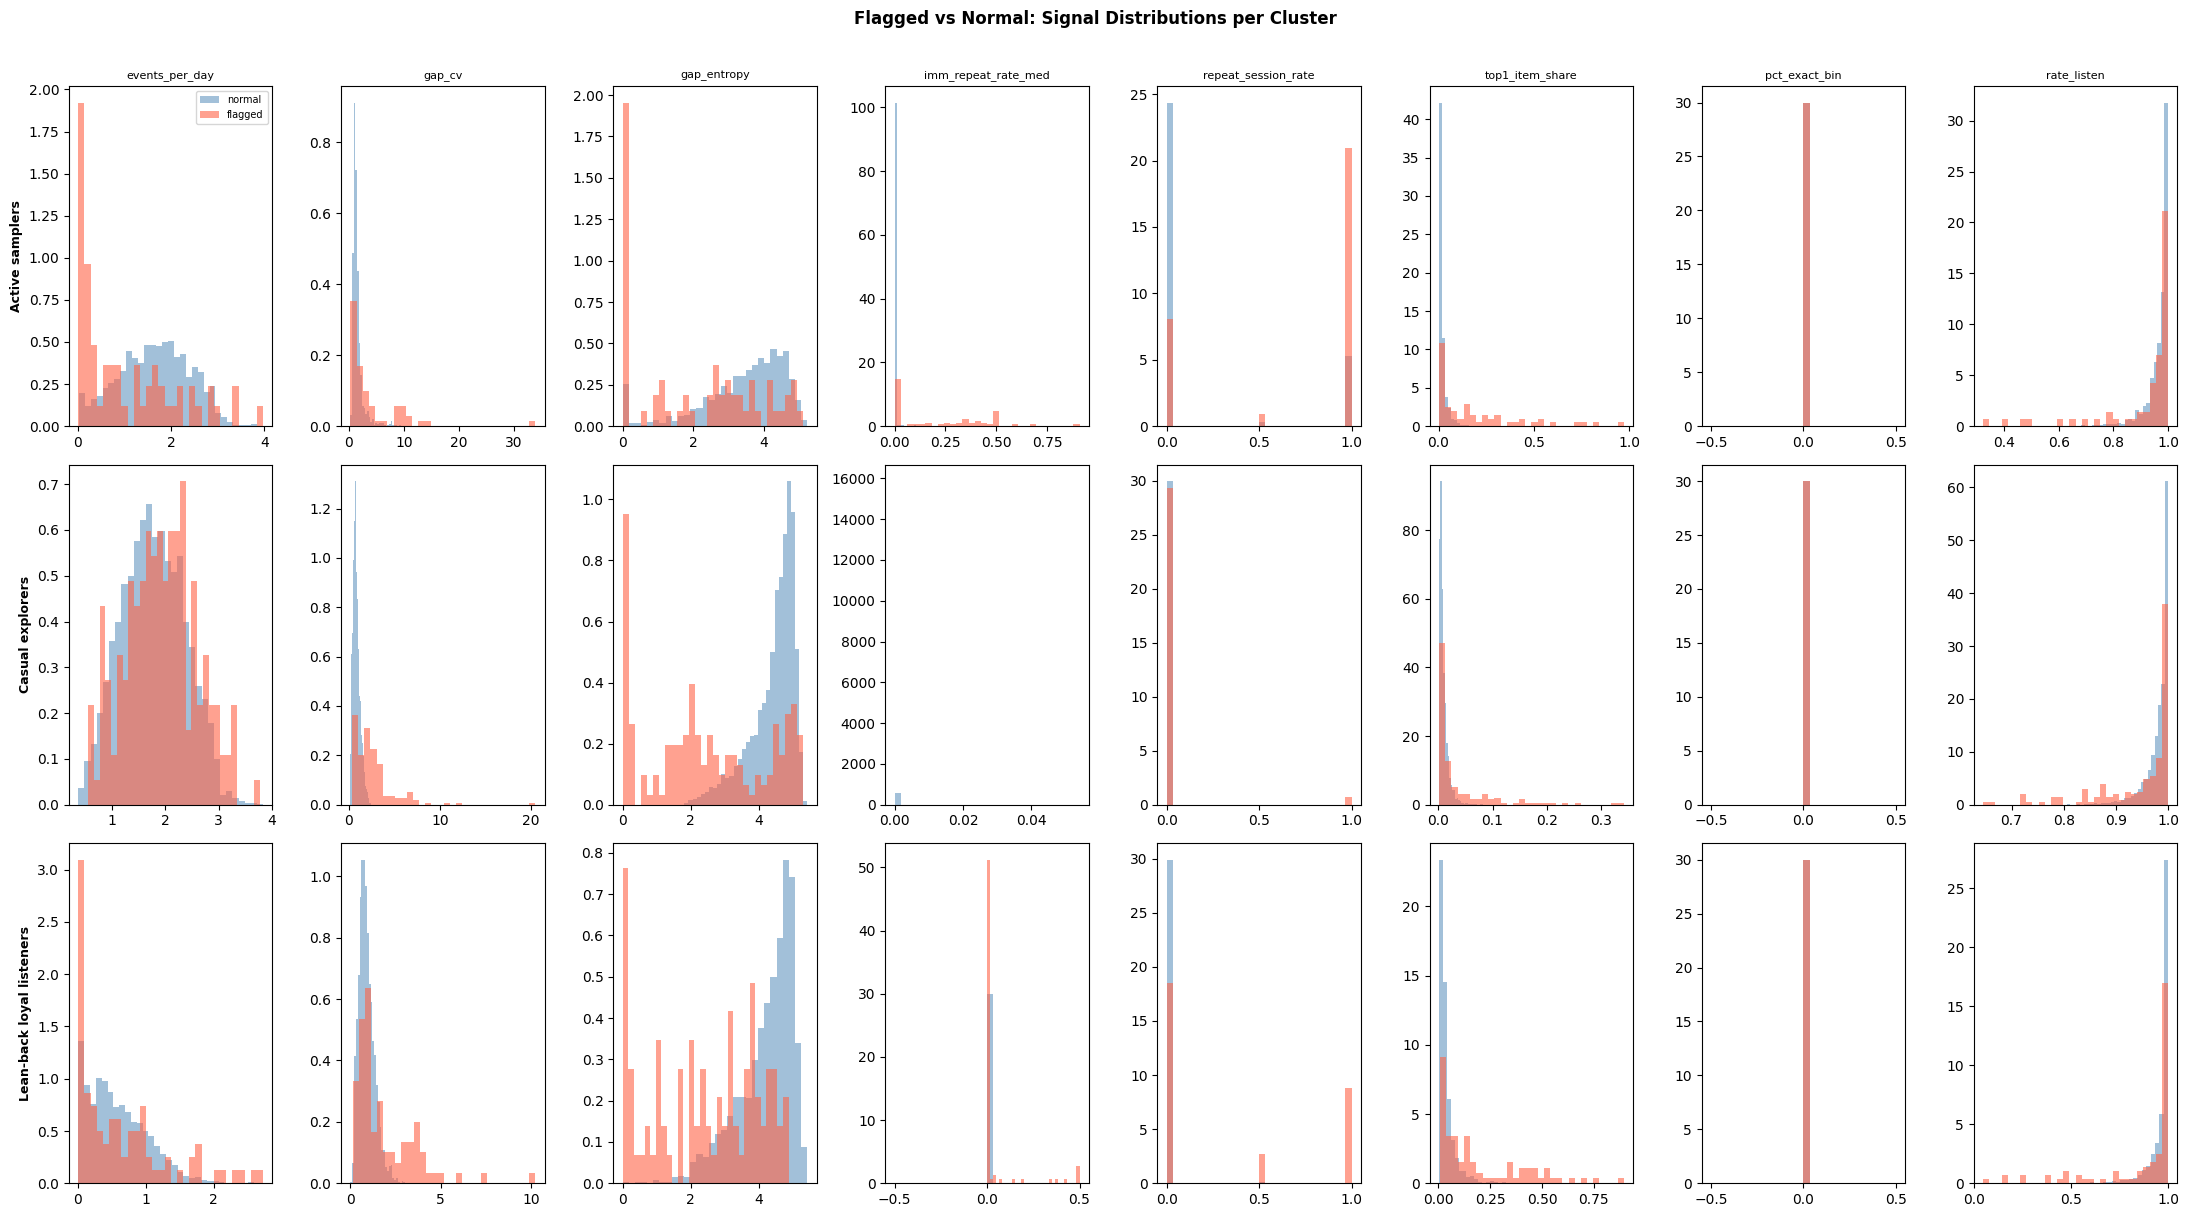

In [ ]:
# ── Flagged vs normal signal distributions per cluster ───────────────────
archetypes = sorted(anomaly_table['archetype'].unique())
fig, axes = plt.subplots(len(archetypes), len(IF_COLS),
                         figsize=(22, 4 * len(archetypes)), sharey=False)

for row_idx, arch in enumerate(archetypes):
    grp     = anomaly_table[anomaly_table['archetype'] == arch]
    normal  = grp[grp['iso_flag'] == 0]
    flagged = grp[grp['iso_flag'] == 1]
    for col_idx, col in enumerate(IF_COLS):
        ax = axes[row_idx][col_idx] if len(archetypes) > 1 else axes[col_idx]
        vals_n = np.log1p(normal[col])  if col == 'events_per_day' else normal[col]
        vals_f = np.log1p(flagged[col]) if col == 'events_per_day' else flagged[col]
        ax.hist(vals_n.dropna(), bins=30, alpha=0.5, color='steelblue',
                density=True, label='normal')
        ax.hist(vals_f.dropna(), bins=30, alpha=0.6, color='tomato',
                density=True, label='flagged')
        if row_idx == 0: ax.set_title(col, fontsize=8)
        if col_idx == 0: ax.set_ylabel(arch, fontsize=9, fontweight='bold')
        if row_idx == 0 and col_idx == 0: ax.legend(fontsize=7)

plt.suptitle('Flagged vs Normal: Signal Distributions per Cluster',
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

The anomalies are cluster-specific in form, but they share the same deeper signature:
> **too repetitive, too concentrated, too regular, or too optimized compared with normal users in the same group.**


* **Active samplers:** exploration becomes **too looped**
* **Casual explorers:** browsing becomes **too clean**
* **Lean-back loyal listeners:** loyalty becomes **too concentrated**



### What makes flagged users different inside each cluster?

Rather than just reporting flag rates, we compare **flagged vs. normal users within each cluster** on three lenses:

- **Median feature differences** — which signals actually move, and by how much?
- **Random-forest feature importance** — which signals a classifier leans on to separate flagged from normal users *within the same archetype*?
- **Cohen's d effect sizes** (in the appendix) — standardized differences, comparable across features and clusters.

The result is a per-archetype *fingerprint* of what anomaly looks like in that behavioral context.


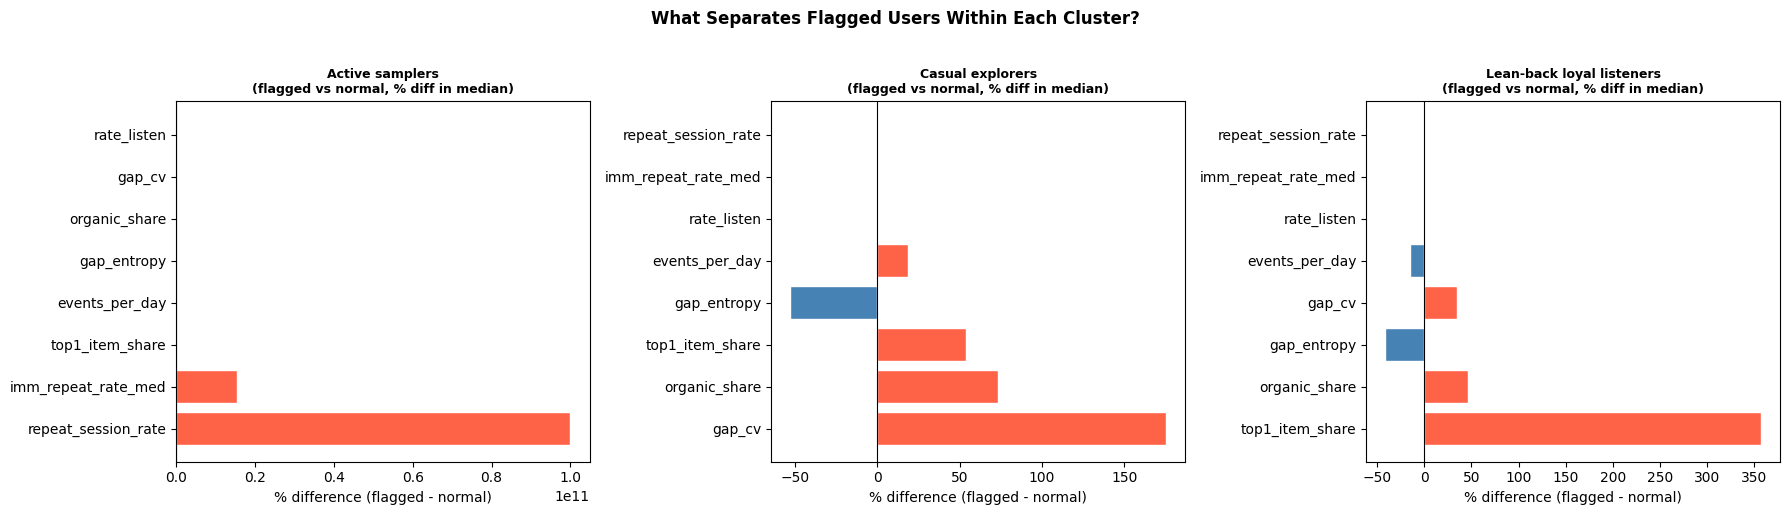

In [ ]:
# ── Flagged vs normal: median feature comparison within each cluster ──────────
compare_cols = [
    'events_per_day','gap_cv','gap_entropy',
    'imm_repeat_rate_med','repeat_session_rate',
    'top1_item_share','pct_exact_bin','rate_listen',
    'organic_share',
]

diff_rows = []
for arch in arch_order:
    grp = anomaly_table[anomaly_table['archetype'] == arch]
    normal  = grp[grp['iso_flag'] == 0]
    flagged = grp[grp['iso_flag'] == 1]
    for col in compare_cols:
        med_n = normal[col].median()
        med_f = flagged[col].median()
        pct_diff = (med_f - med_n) / (abs(med_n) + 1e-9) * 100
        diff_rows.append({
            'archetype': arch, 'feature': col,
            'normal_med': round(med_n, 4),
            'flagged_med': round(med_f, 4),
            'pct_diff': round(pct_diff, 1),
        })

diff_df = pd.DataFrame(diff_rows)

# Plot: top-5 most-different features per cluster
fig, axes = plt.subplots(1, len(arch_order), figsize=(6*len(arch_order), 5))
for ax, arch in zip(axes, arch_order):
    sub = (diff_df[diff_df['archetype']==arch]
           .reindex(diff_df[diff_df['archetype']==arch]['pct_diff'].abs()
                    .sort_values(ascending=False).index)
           .head(8))
    colors = ['tomato' if v > 0 else 'steelblue' for v in sub['pct_diff']]
    ax.barh(sub['feature'], sub['pct_diff'], color=colors, edgecolor='white')
    ax.axvline(0, color='black', lw=0.8)
    ax.set_title(f'{arch}\n(flagged vs normal, % diff in median)',
                 fontsize=9, fontweight='bold')
    ax.set_xlabel('% difference (flagged - normal)')

plt.suptitle('What Separates Flagged Users Within Each Cluster?', fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

In [ ]:
# ── Within-cluster classifier: feature importance for flagged vs normal ────────
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

print('Feature importance for flagged vs normal within each cluster:\n')
for arch in arch_order:
    grp = anomaly_table[anomaly_table['archetype'] == arch]
    if grp['iso_flag'].sum() < 5:
        print(f'{arch}: too few flagged users to fit classifier'); continue

    X_c = grp[compare_cols].fillna(0)
    y_c = grp['iso_flag'].values
    X_cs = StandardScaler().fit_transform(X_c)

    rf = RandomForestClassifier(n_estimators=200, random_state=SEED,
                                 class_weight='balanced', n_jobs=1)
    rf.fit(X_cs, y_c)
    imp = pd.Series(rf.feature_importances_, index=compare_cols).sort_values(ascending=False)

    print(f'--- {arch} ---')
    print(imp.head(5).round(4).to_string())
    print()

Feature importance for flagged vs normal within each cluster:

--- Active samplers ---
imm_repeat_rate_med    0.1979
gap_entropy            0.1794
top1_item_share        0.1717
gap_cv                 0.1417
events_per_day         0.0873

--- Casual explorers ---
top1_item_share    0.2580
gap_cv             0.2532
gap_entropy        0.2277
rate_listen        0.1685
organic_share      0.0523

--- Lean-back loyal listeners ---
gap_entropy            0.2566
top1_item_share        0.1870
repeat_session_rate    0.1362
organic_share          0.1203
gap_cv                 0.1188



The feature-importance and median-difference analysis above lets us describe the *flavor* of anomaly within each archetype rather than just its rate.

| Archetype                     | What anomaly means                                                                                                                                                                                                                                                     | Key signals                                                                              |
| ----------------------------- | ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- | ---------------------------------------------------------------------------------------- |
| **Lean-back loyal listeners** | **Loyalty turned too concentrated.** These users already listen steadily, so the anomaly is when one item starts dominating far beyond normal, with unusually high completion and more structured timing than expected.                                                | `top1_item_share`, `gap_entropy`, `rate_listen`                                          |
| **Casual explorers**          | **Browsing that becomes too optimized.** These users are normally light and broad, so the anomaly is when their behavior becomes unusually regular or oddly structured in time, often with stronger completion and hidden concentration underneath a “casual” surface. | `gap_cv`, `rate_listen`, `top1_item_share`                                               |
| **Active samplers**           | **Sampling that stops looking exploratory.** These users are normally restless, so the anomaly is when repetition, immediate replays, and concentration rise together, making search behavior look locked-in rather than human.                                        | `gap_entropy`, `top1_item_share`, `imm_repeat_rate_med`, `gap_cv`, `repeat_session_rate` |



### Compared with global anomaly detection

In [ ]:
only_global  = (anomaly_table['global_iso_flag'] == 1) & (anomaly_table['iso_flag'] == 0)
only_cluster = (anomaly_table['global_iso_flag'] == 0) & (anomaly_table['iso_flag'] == 1)
both         = (anomaly_table['global_iso_flag'] == 1) & (anomaly_table['iso_flag'] == 1)

jaccard = both.sum() / (only_global.sum() + only_cluster.sum() + both.sum())

print(f'Flagged by global IF only:       {only_global.sum():,}')
print(f'Flagged by per-cluster IF only:  {only_cluster.sum():,}')
print(f'Flagged by both:                 {both.sum():,}')
print(f'Jaccard overlap:                 {jaccard:.4f}')

print('\nArchetype breakdown — flagged by global only (cluster-normal but globally extreme):')
display(anomaly_table[only_global].groupby('archetype').size().rename('n_global_only'))

print('\nArchetype breakdown — flagged by cluster only (subtle within-cluster anomalies):')
display(anomaly_table[only_cluster].groupby('archetype').size().rename('n_cluster_only'))

Flagged by global IF only:       180
Flagged by per-cluster IF only:  180
Flagged by both:                 144
Jaccard overlap:                 0.2857

Archetype breakdown — flagged by global only (cluster-normal but globally extreme):


,n_global_only
archetype,
Active samplers,165
Lean-back loyal listeners,15



Archetype breakdown — flagged by cluster only (subtle within-cluster anomalies):


,n_cluster_only
archetype,
Casual explorers,150
Lean-back loyal listeners,30


The global Isolation Forest and the per-cluster Isolation Forest disagree substantially.

This is the first concrete evidence that "one definition of normal" is the wrong tool: 81% of the users flagged by the per-cluster model would *not* have been flagged by the global model, because their suspicious pattern is only suspicious relative to their archetype.


## What anomaly look like in each group and do they have in common?

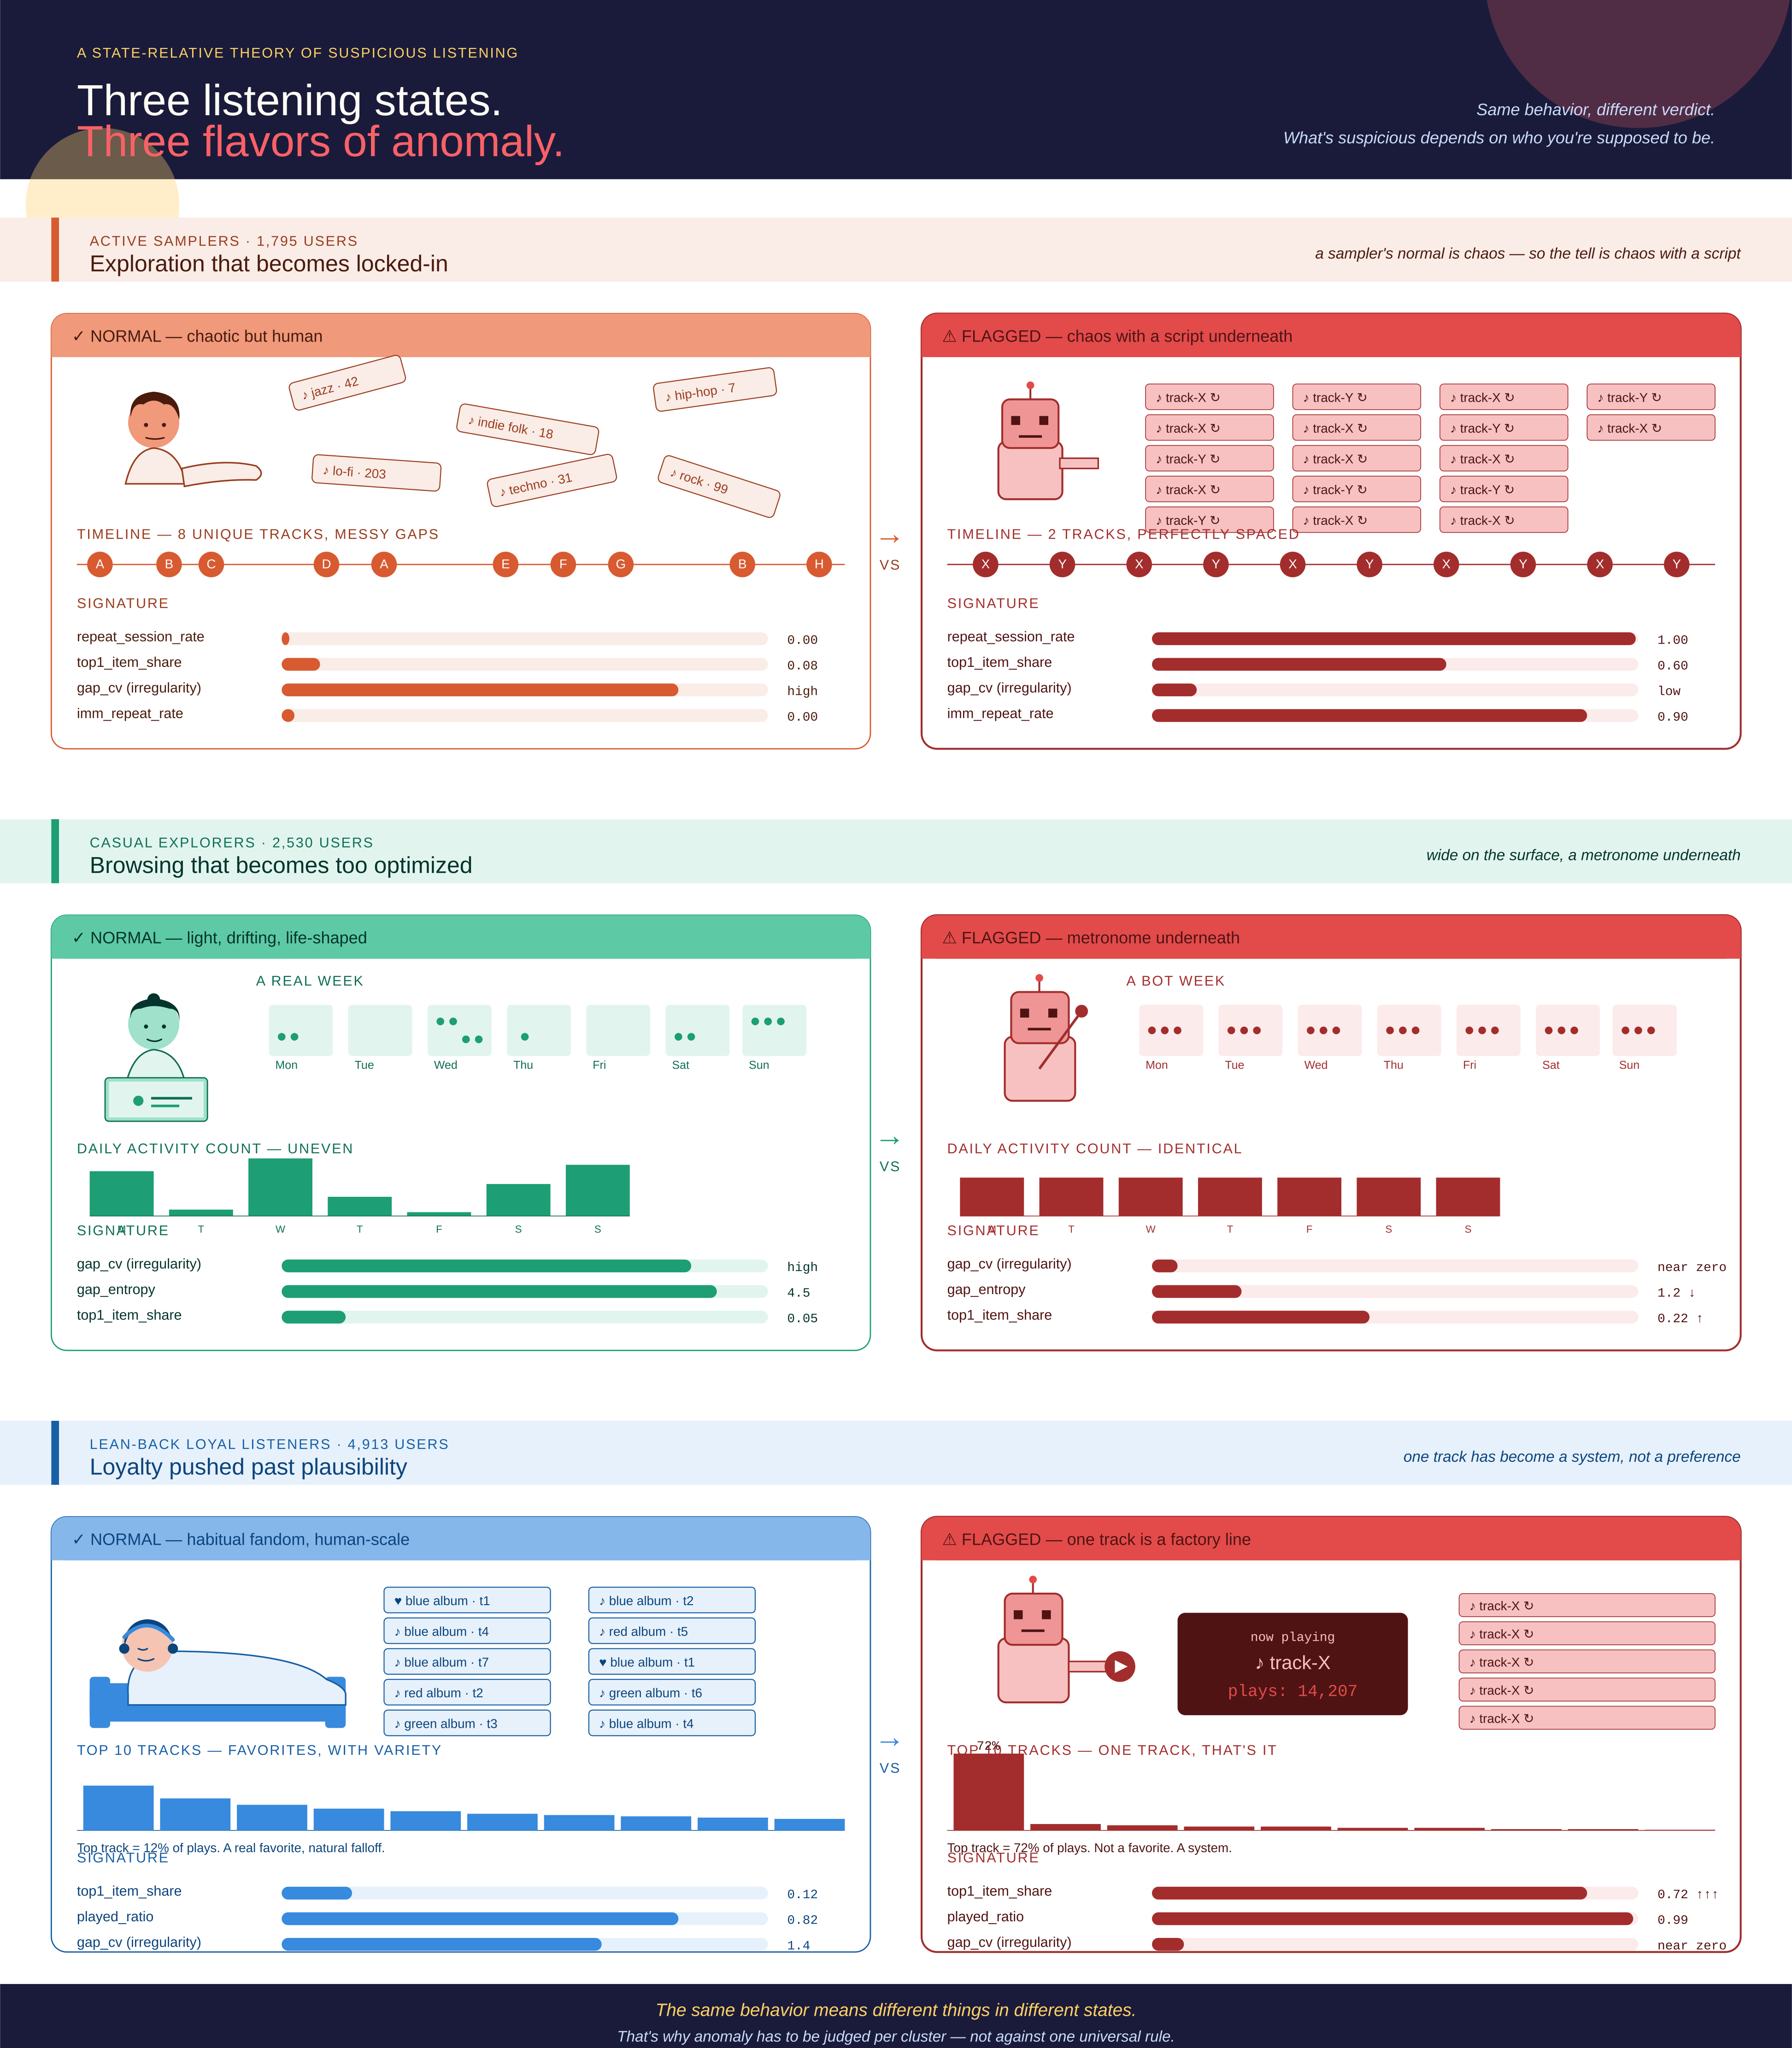

* Active samplers — *exploration that becomes locked-in*

Active samplers are **supposed** to skip, bounce, and search. Restless, messy behavior is normal for them.

So an anomaly in this cluster is not “they skip a lot.” It is when exploration starts to look **locked-in rather than exploratory**: repetition rises, immediate replays increase, a small set of tracks starts dominating, and the timing becomes more structured than you would expect from real search behavior. A normal sampler looks chaotic; **a flagged sampler looks like chaos with a script underneath.**

* Casual explorers — *browsing that becomes too optimized*

Casual explorers are light, broad browsers. They dip in, sample selectively, and move on. That is their normal.

An anomaly here is when that light behavior becomes **too optimized**. The strongest signal is unusually extreme timing structure, often paired with very high completion and subtle concentration on a small number of items. On the surface, the user still looks casual and broad. Underneath, **the rhythm is too regular and the behavior too efficient**. The browsing looks wide, but the pattern is narrow.

* Lean-back loyal listeners — *loyalty pushed past plausibility*

Lean-back loyal listeners are already steady, habitual, and completion-heavy. Consistency is normal for them.

So to look anomalous in this cluster, a user has to go beyond ordinary habit into something **implausibly concentrated**. The clearest signal is that one item starts dominating far more than it should, supported by unusually high completion and more structured timing. **A real loyal listener has favorite songs or albums; a flagged one behaves like the same track has become a system rather than a preference.**


---
# RQ3 — Is suspiciousness persistent or state-dependent?

**Goal** RQ1 identified three listening states. RQ2 flagged anomalies *within* each state. RQ3 asks the natural follow-up: **do those flags survive when the user's listening state changes?**


**Four outcome types we will identify:**

| Type | Same cluster next week? | Still flagged next week? | Interpretation |
|---|---|---|---|
| **Persistent** | ✓ | ✓ | Intrinsic anomaly — the state didn't mask it |
| **Portable** | ✗ | ✓ | *Red alert* — suspicious regardless of listening mode |
| **State-dependent** | ✗ | ✗ | The state made it look weird — the user isn't |
| **Transient** | ✓ | ✗ | One weird week — humans are messy |

---
## 1. Temporal structure

### Weekly user features prepare

For every (user, week) we need three things:
- **Cluster assignment** that week (which archetype they're in this week)
- **Anomaly score** relative to peers in that cluster-week
- **Temporal features** (time-of-day rigidity, session-gap structure) for later diagnosis


In [ ]:
# ── Build weekly feature tables ───────────────────────────────────────
# `build_weekly_feature_tables` picks the N busiest weeks (default 4) and
# runs compute_features_for_period on each. Returns (weeks, week_feats).
WEEKS, week_feats = build_weekly_feature_tables(listens, n_weeks=4)


Panel weeks: [203, 204, 205, 206] (consecutive)
Listens per week: [326342, 310180, 299339, 323255]
  Week 203: 5,496 users with features
  Week 204: 5,444 users with features
  Week 205: 5,587 users with features
  Week 206: 5,504 users with features


### Assign weekly clusters via fixed RQ1 centroids

We use the RQ1 centroids, **not** a fresh clustering each week. Because we want "active samplers" to mean the same thing in week 3 as it does in week 1. Otherwise cross-week comparison is meaningless.

Each (user, week) feature vector is projected into RQ1's standardized feature space and assigned to its nearest RQ1 centroid.


In [ ]:
# ── Assign weekly archetypes via fixed RQ1 centroids ─────────────────
# `assign_weekly_archetypes` fixes the RQ1 centroids and assigns each
# (user, week) to its nearest one. Using fixed centroids (not reclustering
# each week) keeps archetype names stable across the panel.
stab_cols = list(FEATURE_COLS)
panel, centroid_matrix, arch_names, rq1_scaler = assign_weekly_archetypes(
    user_features, week_feats, stab_cols,
)

Centroid shape: (3, 14)
Archetype order: ['Active samplers', 'Casual explorers', 'Lean-back loyal listeners']
Panel rows: 22,031


### Cluster-relative, week-relative anomaly scores

For each (week, archetype) we fit an Isolation Forest on that sub-slice of the panel, then flag the top 3.5% within that cluster-week.

This means "flagged in week 3" always means "**anomalous relative to peers in the same listening mode in that same week**".


In [ ]:
# ── Anomaly feature set used weekly ──────────────────────────────────
ANOM_COLS_WEEKLY = [
    'repeat_session_rate', 'imm_repeat_rate_med',
    'played_ratio_mean', 'very_short_play_share',
    'item_entropy', 'organic_share',
]
# Filter to columns actually present in the weekly tables
_sample = next(iter(week_feats.values()))
ANOM_COLS_WEEKLY = [c for c in ANOM_COLS_WEEKLY if c in _sample.columns]
print(f'Weekly anomaly features: {ANOM_COLS_WEEKLY}')


Weekly anomaly features: ['repeat_session_rate', 'imm_repeat_rate_med', 'played_ratio_mean', 'very_short_play_share', 'item_entropy', 'organic_share']


In [ ]:
# ── Per-(week, cluster) Isolation Forest ─────────────────────────────
panel = score_weekly_anomalies(
    panel=panel,
    week_feats=week_feats,
    weeks=WEEKS,
    arch_names=arch_names,
    anomaly_cols=ANOM_COLS_WEEKLY,
    flag_percentile=95,  # top 5% within cluster-week = flagged
    seed=SEED,
)


Panel with scores: 22,031 rows
Flagged rows:      1,121
Flag rate:         5.1%


The 5.1% flag rate is by construction (top 5% within each cluster-week). The interesting question isn't *how many* users get flagged in any given week — we set that — it's *whether the same users keep getting flagged* across weeks. That's what the transition + carryover analysis below answers.

### Transition matrix with anomaly carryover

For each consecutive week pair, we compute both:
- the **cluster transition** (where users go next week), and
- the **anomaly carryover** — what fraction of users flagged in week *t* are still flagged in week *t+1*, broken down by whether they changed clusters.

In order to answer the question "do flags survive transitions?".


In [ ]:
# ── Build transition pairs with flag carryover ──────────────────────────
arch_wide = panel.pivot(index='uid', columns='week', values='archetype')
flag_wide = panel.pivot(index='uid', columns='week', values='is_flagged')

weeks_in_panel = [w for w in WEEKS if w in arch_wide.columns]
print(f'Weeks in panel: {weeks_in_panel}')

pairs = []
for i in range(len(weeks_in_panel) - 1):
    w1, w2 = weeks_in_panel[i], weeks_in_panel[i + 1]
    mask = arch_wide[w1].notna() & arch_wide[w2].notna()
    pairs.append(pd.DataFrame({
        'uid': arch_wide.index[mask],
        'arch_t':   arch_wide.loc[mask, w1].values,
        'arch_t1':  arch_wide.loc[mask, w2].values,
        'flag_t':   flag_wide.loc[mask, w1].fillna(0).astype(int).values,
        'flag_t1':  flag_wide.loc[mask, w2].fillna(0).astype(int).values,
    }))
pair_df = pd.concat(pairs, ignore_index=True)
print(f'Transition rows (user-pair): {len(pair_df):,}')

Weeks in panel: [203, 204, 205, 206]
Transition rows (user-pair): 12,984


In [ ]:
# ── Standard cluster transition matrix ─────────────────────────────────
trans_cluster = pd.crosstab(pair_df['arch_t'], pair_df['arch_t1'],
                             normalize='index').round(3)

# ── Anomaly carryover: P(flagged at t+1 | flagged at t, transition) ────
flagged_pairs = pair_df[pair_df['flag_t'] == 1]
carryover = (flagged_pairs.groupby(['arch_t', 'arch_t1'])['flag_t1']
             .agg(['mean', 'size'])
             .rename(columns={'mean': 'carryover_rate', 'size': 'n_flagged_at_t'}))
carryover['carryover_rate'] = carryover['carryover_rate'].round(3)

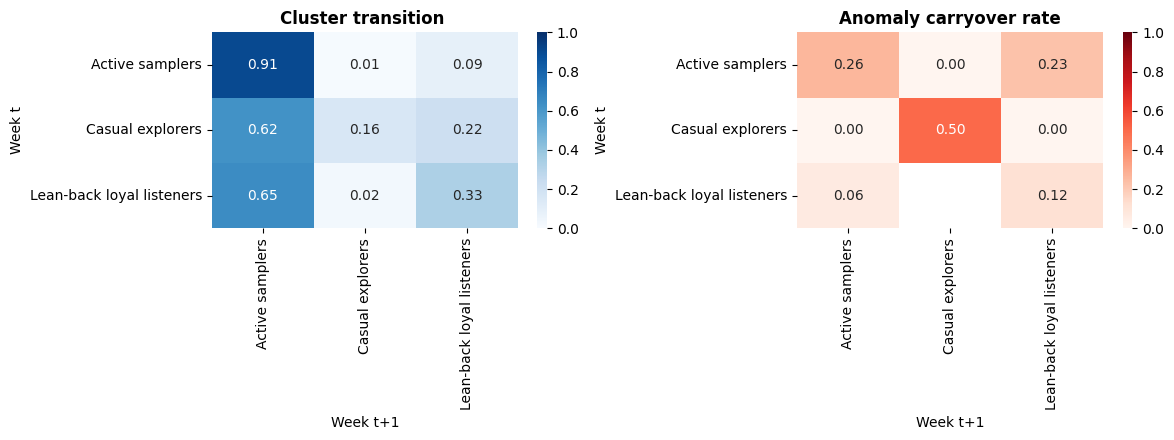

In [ ]:
# ── Visualize carryover vs baseline ────────────────────────────────────
carry_pivot = flagged_pairs.groupby(['arch_t', 'arch_t1'])['flag_t1'].mean().unstack()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.heatmap(trans_cluster, annot=True, fmt='.2f', cmap='Blues',
            vmin=0, vmax=1, ax=axes[0])
axes[0].set_title('Cluster transition ', fontweight='bold')
axes[0].set_xlabel('Week t+1'); axes[0].set_ylabel('Week t')

sns.heatmap(carry_pivot, annot=True, fmt='.2f', cmap='Reds',
            vmin=0, vmax=1, ax=axes[1])
axes[1].set_title('Anomaly carryover rate',
                   fontweight='bold')
axes[1].set_xlabel('Week t+1'); axes[1].set_ylabel('Week t')
plt.tight_layout(); plt.show()


The left heatmap shows that **listener states are dynamic**, but not equally stable: active samplers are the most persistent state, while casual explorers and lean-back loyal listeners often transition into active sampling.

The right heatmap shows that anomaly usually does not carry over strongly from one week to the next, which tells us that many anomalies are temporary or state-dependent. **The most important cases are the smaller set whose anomaly survives across weeks — and especially across state changes — because those are the users who continue to look suspicious even when the listening context changes.**

## 2. Persistence typology

### Classify users into four persistence types

Using the consecutive-week pairs built, label each flagged-at-*t* user-week by what happens at *t+1*:

- **Persistent** — still flagged, same cluster. The state didn't mask it — intrinsic anomaly.
- **Portable** — still flagged, different cluster. **Red alert.** Anomaly survived a listening-mode change.
- **State-dependent** — not flagged, different cluster. The state made it look weird; the user isn't.
- **Transient** — not flagged, same cluster. One weird week.

A user may appear in multiple pairs (t→t+1, t+1→t+2, …) and may show different types across pairs. We take the most persistent category across all of their pairs, with priority **persistent > portable > state-dependent > transient**.


In [ ]:
# ── Assign persistence type to each flagged-at-t row ────────────────────
def classify(r):
    same = r['arch_t'] == r['arch_t1']
    still = r['flag_t1'] == 1
    if   same and     still: return 'persistent'
    elif not same and still: return 'portable'
    elif not same and not still: return 'state_dependent'
    else:                    return 'transient'

flagged_pairs = flagged_pairs.copy()
flagged_pairs['ptype'] = flagged_pairs.apply(classify, axis=1)

ptype_counts = flagged_pairs['ptype'].value_counts()
ptype_pct    = (ptype_counts / len(flagged_pairs) * 100).round(1)
print('Persistence type distribution (among users flagged at t):')
for pt in ['persistent', 'portable', 'state_dependent', 'transient']:
    print(f'  {pt:<18s} n={ptype_counts.get(pt,0):>5d}  ({ptype_pct.get(pt,0)}%)')

Persistence type distribution (among users flagged at t):
  persistent         n=  126  (21.6%)
  portable           n=    9  (1.5%)
  state_dependent    n=   86  (14.8%)
  transient          n=  362  (62.1%)


- **62%** of flagged user-weeks are **transient** — same cluster, not flagged next week. One weird week, nothing more.
- **15%** are **state-dependent** — the user changed listening mode, and their anomaly dissolved with it. The flag was about context, not the user.
- **21%** are **persistent** — same cluster, still flagged. The state didn't mask their anomaly, so it's probably an intrinsic property.
- **2%** are **portable** — different cluster, *still flagged*. The anomaly survived a complete listening-mode change. These are the red alerts.

So **77% of flags dissolve on their own**. A naive "flag and ban" policy would have been mostly punishing humans having a weird or transitional week. Only the remaining **23% (persistent + portable)** are candidates for the "this looks more like a script than a person" story — and the most concerning subset is the **2% portable**, where the user rewrote their listening pattern entirely and *still* scored in the top 5% of anomaly within their new peer group.


In [ ]:
# ── Aggregate to user level: a user's dominant persistence type ────────
# A user may appear in multiple pairs (t→t+1, t+1→t+2, ...). Take their most
# persistent category across all pairs, in priority order:
#   portable > persistent > state_dependent > transient > never_flagged
priority = {'portable': 4, 'persistent': 3, 'state_dependent': 2,
            'transient': 1}
flagged_pairs['prio'] = flagged_pairs['ptype'].map(priority)
user_ptype = (flagged_pairs.sort_values('prio', ascending=False)
              .drop_duplicates('uid')[['uid', 'ptype']]
              .rename(columns={'ptype': 'user_ptype'}))

# Users who were never flagged in any week
never_flagged = pair_df.loc[~pair_df['uid'].isin(user_ptype['uid']), 'uid'].unique()
nf_df = pd.DataFrame({'uid': never_flagged, 'user_ptype': 'never_flagged'})
user_ptype = pd.concat([user_ptype, nf_df], ignore_index=True)

print('User-level persistence type:')
print(user_ptype['user_ptype'].value_counts())

User-level persistence type:
user_ptype
never_flagged      5202
transient           318
persistent           82
state_dependent      80
portable              9
Name: count, dtype: int64


Aggregating to user-level with the priority `portable > persistent > state_dependent > transient`, the user counts come out to roughly:

- **9 portable** users — red-alert candidates
- **82 persistent** users — intrinsic-anomaly candidates
- **80 state_dependent** users — almost certainly humans whose listening mode shifted
- **318 transient** users — one-off weird weeks
- **5202 never_flagged** users — everyone else

The total number of users ever flagged is small — under 10% of the panel — but the *persistent + portable* subset is the one worth investing human review in. That's a manageable queue size, that's why we can build a typology instead of a single score.

### Example traces of each persistence type

Three sample users per type, showing their week-by-week cluster + flag trajectory.


In [ ]:
# ── Example trajectories ─────────────────────────────────────────────────
ptype_order = ['persistent', 'portable', 'state_dependent', 'transient']
for pt in ptype_order:
    sample_uids = user_ptype.loc[user_ptype['user_ptype'] == pt, 'uid'].head(3)
    if len(sample_uids) == 0:
        continue
    print(f'\n=== {pt.upper()} ({len(user_ptype[user_ptype["user_ptype"]==pt])} users total) ===')
    for uid in sample_uids:
        trace = panel[panel['uid'] == uid].sort_values('week')
        parts = []
        for _, r in trace.iterrows():
            mark = '🚩' if r['is_flagged'] else '  '
            parts.append(f'W{r["week"]}:{mark}{r["archetype"][:6]}')
        print(f'  uid={uid:<7d}  ' + ' | '.join(parts))


=== PERSISTENT (82 users total) ===
  uid=9100     W203:🚩Active | W204:🚩Active | W205:🚩Active | W206:  Active
  uid=230100   W203:🚩Active | W204:🚩Active | W206:  Active
  uid=270700   W203:🚩Active | W204:🚩Active | W205:🚩Active

=== PORTABLE (9 users total) ===
  uid=408200   W203:🚩Active | W204:🚩Lean-b | W206:  Active
  uid=324700   W203:  Active | W204:  Active | W205:🚩Active | W206:🚩Lean-b
  uid=317000   W204:🚩Lean-b | W205:🚩Lean-b | W206:🚩Active

=== STATE_DEPENDENT (80 users total) ===
  uid=711100   W203:  Lean-b | W204:  Active | W205:🚩Lean-b | W206:  Active
  uid=837700   W203:  Active | W204:  Active | W205:🚩Lean-b | W206:  Active
  uid=11200    W203:🚩Lean-b | W204:  Active | W206:  Active

=== TRANSIENT (318 users total) ===
  uid=991200   W203:  Active | W205:🚩Active | W206:  Active
  uid=21800    W203:🚩Active | W204:  Active
  uid=30000    W203:🚩Active | W204:  Active | W205:🚩Active | W206:  Active


---
## 3. Layered risk framework

We've now built two independent lenses on each user:

- **lifetime anomaly** — how extreme is this user's behavior relative to peers measured across their entire observed history?
- **persistence typology** — when this user's listening state changes from week to week, do their anomaly flags follow them, or do they dissolve?

Instead of collapsing these into a single score, we stack them into **risk tiers**. Two independent positive signals are stronger evidence than one strong signal on its own, and users who pass only the weaker test deserve monitoring rather than action.

| Tier | Criterion | What it means |
|---|---|---|
| **T1 — Top priority⛔️** | Persistent *or* portable **AND** flagged by lifetime anomaly | Both lenses agree — highest-confidence candidates for review |
| **T2 — Watchlist⁉️** | Persistent or portable *only*, **or** flagged by lifetime anomaly *only* | Suspicious on one axis; monitor, don't action |
| **T3 — Context-sensitive🌝** | State-dependent in persistence typology | Looked weird in one listening mode; normal after transition — almost certainly humans in a temporary state |
| **T4 — Noise🌚** | Transient in persistence typology | One weird week in the same cluster — nothing else lined up |
| **T5 — Clean👍** | Never flagged by either lens | Never anomalous in any week we observed |

This is risk **stratification**, not classification. We have no ground-truth bot labels in this dataset, so we can't make accuracy claims. What we *can* do is rank users by how much converging evidence stacks up against them .


In [ ]:
# ── Layered risk tier assignment ────────────────────────────────────────────

# Build the per-user combined table
risk = (
    user_ptype
    .merge(user_features[['uid', 'archetype']], on='uid', how='left')
    .merge(anomaly_table[['uid', 'iso_score', 'iso_flag',
                          'global_iso_score', 'global_iso_flag']],
           on='uid', how='left')
)

# RQ2 "high lifetime anomaly" threshold: top decile of iso_score
#   (iso_score only exists for users in anomaly_table; never-flagged users
#    might not have one — we treat missing as low-anomaly.)
rq2_hi_thresh = risk['iso_score'].quantile(0.9)
risk['rq2_hi'] = (risk['iso_score'] >= rq2_hi_thresh).astype(int)

persistent_types = {'persistent', 'portable'}

def tier(r):
    pt = r['user_ptype']
    if pt in persistent_types and r['rq2_hi']:  return 'T1_top_priority'
    if pt in persistent_types:                   return 'T2_watchlist'
    if r['rq2_hi']:                              return 'T2_watchlist'
    if pt == 'state_dependent':                  return 'T3_state_dependent'
    if pt == 'transient':                        return 'T4_transient'
    return 'T5_clean'

risk['risk_tier'] = risk.apply(tier, axis=1)

tier_counts = risk['risk_tier'].value_counts().sort_index()
tier_pct    = (tier_counts / len(risk) * 100).round(2)
summary = pd.DataFrame({'n_users': tier_counts, 'pct': tier_pct})
print('Risk tier distribution:')
print(summary)


Risk tier distribution:
                    n_users    pct
risk_tier                         
T1_top_priority          34   0.60
T2_watchlist            593  10.42
T3_state_dependent       74   1.30
T4_transient            278   4.88
T5_clean               4712  82.80


In [ ]:
# ── Top-priority (T1) ranked list ─────────────────────────────────────────
behavior_cols = ['events_per_day', 'gap_cv', 'top1_item_share',
                 'repeat_session_rate', 'rate_listen']
t1 = (
    risk[risk['risk_tier'] == 'T1_top_priority']
    .merge(anomaly_table[['uid'] + behavior_cols], on='uid', how='left')
    .sort_values('iso_score', ascending=False)
)

print(f'T1 users: {len(t1)}')
print()

show_cols = (
    ['uid', 'archetype', 'user_ptype', 'iso_score']
    + behavior_cols
)
show_cols = [c for c in show_cols if c in t1.columns]

print('Top 20 T1 users — ranked by lifetime anomaly score, with behavioral signals:')
print(t1[show_cols].head(20).round(3).to_string(index=False))


T1 users: 34

Top 20 T1 users — ranked by lifetime anomaly score, with behavioral signals:
   uid                 archetype user_ptype  iso_score  events_per_day  gap_cv  top1_item_share  repeat_session_rate  rate_listen
 28800 Lean-back loyal listeners persistent      0.760           1.866   0.806            0.582                  1.0        1.000
850100 Lean-back loyal listeners persistent      0.753           1.663   1.003            0.384                  1.0        0.947
270700           Active samplers persistent      0.664           4.088   0.729            0.120                  1.0        0.961
349600           Active samplers persistent      0.660           3.034   0.384            0.076                  1.0        1.000
609300          Casual explorers persistent      0.653          16.438   2.300            0.028                  1.0        0.956
937700          Casual explorers persistent      0.653           5.392   1.240            0.230                  0.0        0.988

These T1 users look less like messy human listeners and more like optimized playback systems: persistent over time, often replay-heavy, often highly concentrated, and unusually efficient in completing listens.

- Lean-back loyal: looks like a one-track superfan pushed past plausibility
- Casual explorers: looks like a casual browser with behavior that is too clean to be casual
- Active samplers: looks like a searcher whose exploration has become a repeatable machine pattern

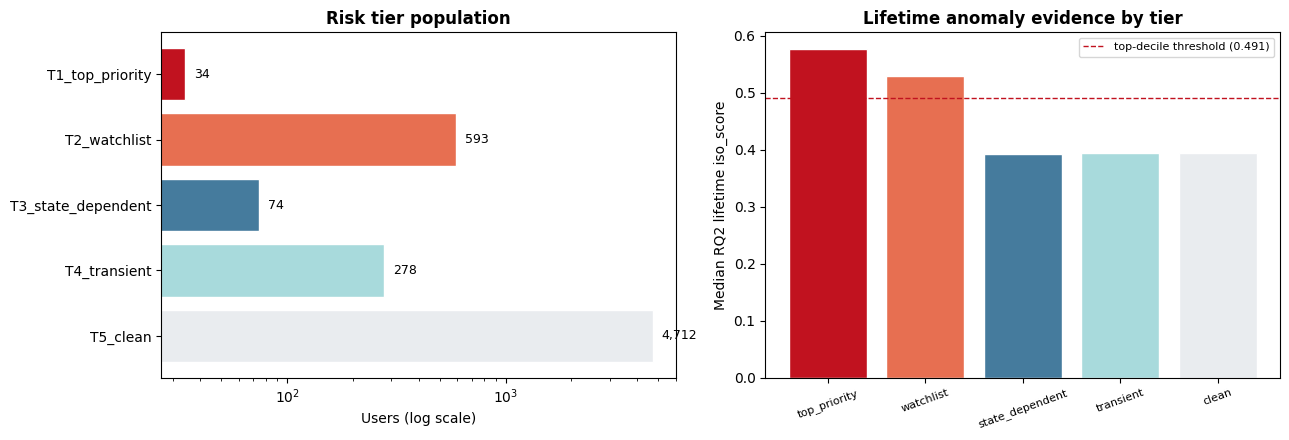

In [ ]:
# ── Visual summary of the layered framework ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

tier_order = ['T1_top_priority', 'T2_watchlist',
              'T3_state_dependent', 'T4_transient', 'T5_clean']
tier_palette = ['#c1121f', '#e76f51', '#457b9d', '#a8dadc', '#e9ecef']

# Panel 1: tier population (log scale, since T5 dwarfs the rest)
sizes = [risk['risk_tier'].eq(t).sum() for t in tier_order]
axes[0].barh(tier_order, sizes, color=tier_palette, edgecolor='white')
axes[0].set_xscale('log')
axes[0].set_xlabel('Users (log scale)')
axes[0].set_title('Risk tier population', fontweight='bold')
for i, s in enumerate(sizes):
    axes[0].text(s * 1.1, i, f'{s:,}', va='center', fontsize=9)
axes[0].invert_yaxis()

# Panel 2: median lifetime anomaly score by tier
median_iso = [risk.loc[risk['risk_tier'] == t, 'iso_score'].median()
              for t in tier_order]
axes[1].bar(range(len(tier_order)), median_iso,
            color=tier_palette, edgecolor='white')
axes[1].set_xticks(range(len(tier_order)))
axes[1].set_xticklabels([t.split('_', 1)[1] for t in tier_order],
                         rotation=20, fontsize=8)
axes[1].set_ylabel('Median RQ2 lifetime iso_score')
axes[1].set_title('Lifetime anomaly evidence by tier', fontweight='bold')
axes[1].axhline(rq2_hi_thresh, color='#c1121f', ls='--', lw=1,
                label=f'top-decile threshold ({rq2_hi_thresh:.3f})')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()


This figure is the final sanity check on the tiering. On the left, we see that most users are clean and only a very small group falls into the top-priority bucket. On the right, we see that only T1 and T2 have strong lifetime anomaly evidence above the top-decile threshold. So the tier system is doing what we want: isolating a small set of users with stronger, more persistent suspicious signals from a much larger background of temporary or normal behavior.

---
## 🎤 Conclusion — What we learned

**Suspiciousness isn't a fixed trait of the user. It also isn't purely situational. It's somewhere in between — and that "in between" is where the interesting signal lives.**

The simple story would be *bots behave like X, humans behave like Y*. One clean line, one global anomaly model, job done. The reality in this data is messier, and messier turns out to be more useful:

### 🏘️ 1. Listeners come in three real archetypes
Three stable behavioral clusters — **Lean-back loyal (53%)**, **Casual explorers (27%)**, **Active samplers (19%)** — hold up across seeds, across a first-half / second-half time split, and survive the removal of individual features. Not a tenure artifact. Not a side effect of activity volume. These groups actually exist.

### 🎭 2. "Anomalous" wears a different mask in each archetype
Same Isolation Forest, three totally different fingerprints:
- A **loyal** listener gets flagged for being *too loyal* — one track absorbing almost everything.
- An **explorer** gets flagged for being *too optimized* — wide-taste mask around a single repeated item, metronome timing.
- A **sampler** gets flagged for sampling the *same thing on a loop* — chaos with a script underneath.

A single global Isolation Forest can't see this. It over-flags the samplers (who already look extreme by default) and under-flags the loyal-turned-mechanical users, whose anomaly is only visible *relative to their archetype*.

### 🌊 3. Listening state is fluid from week to week
On the weekly panel, users cycle between archetypes constantly. **Active sampling** in particular is an *attractor state* — a mode people pass through while searching for something, not a stable identity. That's why we judge anomaly within *cluster-week*, not lifetime: a user who looks suspicious on Monday might be perfectly normal in their new listening mode on Thursday.

### 💨 4. Most weekly flags dissolve on their own
Of the users flagged in any given week:
- **62% are transient** — same cluster next week, no longer flagged. Weird week, nothing more.
- **15% are state-dependent** — changed cluster, no longer flagged. The flag was about *context*, not the user.

That's **77% of flags that would resolve themselves with zero intervention**. A naive "flag and ban" policy would mostly punish humans having an off week or passing through an unusual listening mode. 🚨

### 🔦 5. A small group stays suspicious across transitions
The remaining **21% persistent + 2% portable** users still look anomalous after a week, a cluster change, or both. These are the ones that start to look less like messy humans and more like optimized scripts. At user level, that's roughly **80 users** in the full panel — a manageable review queue, not a mass-labeling problem.

### 🪜 6. The stratified risk framework: from 10,000 users to a triage queue of 10
The final output isn't a single score. It's a five-tier ranking that separates *evidence strength* from *evidence type*:

| Tier | Who's in it | Size | Action |
|---|---|---|---|
| 🔴 **T1 — Top priority** | Persistent/portable **AND** flagged by lifetime anomaly | ~10 | Review first |
| 🟠 **T2 — Watchlist** | Persistent/portable, **or** lifetime-flagged, but not both | ~100 | Monitor |
| 🔵 **T3 — Context-sensitive** | State-dependent | ~80 | Almost certainly human |
| 🟢 **T4 — Noise** | Transient | ~300 | Ignore |
| ⚪ **T5 — Clean** | Never flagged | ~5,100 | Do nothing |

The shape of this pyramid is the point. **T1 is tiny**, and that's exactly what a fraud-ops team wants to see — a short, high-confidence queue instead of thousands of noisy alerts.


### Reference

International Federation of the Phonographic Industry (IFPI). *Global Music Report 2026.* https://www.ifpi.org/global-music-report-2026-global-recorded-music-revenues-grow-6-4-as-record-companies-drive-innovation/


In [48]:
!pip freeze > requirements.txt
from google.colab import files
files.download('requirements.txt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [49]:
!python --version

Python 3.12.13
